# W4D5 — Generating Digits with a GAN — Lab

**Week 4 · Day 5 · CNNs & Model Fine-Tuning** · Lab

Every network you have trained so far took an image in and gave a label out. Today's runs the other
way. It takes **64 random numbers** in and gives a **handwritten digit** out — a digit that is not in
MNIST, that nobody drew, and that no one ever told the network how to draw.

The trick is a game between two networks. A **generator** turns noise into images. A
**discriminator** looks at an image and says whether it came from MNIST or from the generator. Each is
trained to beat the other, and the generator only ever learns through the discriminator's verdicts.
That is a **GAN** — a generative adversarial network.

Three things, in order:

- **Build the two players** as `nn.Module` classes and write the training step that alternates
  between them. It is eight lines, and two of them are where every GAN bug lives.
- **Watch it learn** from fixed noise, and measure what it makes with a classifier, because a GAN
  has no accuracy to print.
- **Break it on purpose.** Remove the normalisation layers from the two networks and the generator
  stops drawing ten digits and draws one, over and over. That failure is called **mode collapse**, and it is the reason GANs have a
  reputation.

**Time budget:** ~115 minutes. Sections 1–2 are the lab; Section 3 is a stretch you may finish at home.

<div dir="rtl" align="right">

# الأسبوع ٤ · اليوم ٥ — توليد الأرقام بشبكة GAN

**الأسبوع الرابع · اليوم الخامس · الشبكات الالتفافية وضبط النماذج** · معمل

كل شبكة درّبتها حتى الآن أخذت صورة وأعطت تصنيفًا. وشبكة اليوم تعمل في الاتجاه المعاكس: تأخذ **٦٤ عددًا
عشوائيًا** وتُعطي **رقمًا مكتوبًا بخط اليد** — رقمًا ليس في MNIST، ولم يرسمه أحد، ولم يُخبر أحدٌ الشبكةَ قطّ
كيف ترسمه.

والحيلة لعبة بين شبكتين. **المولِّد** (generator) يحوّل الضجيج إلى صور. و**المميِّز** (discriminator) ينظر إلى
الصورة ويقول أجاءت من MNIST أم من المولِّد. وتُدرَّب كلٌّ منهما لتهزم الأخرى، ولا يتعلّم المولِّد إلا عبر أحكام
المميِّز. وهذه هي **GAN** — الشبكة التوليدية التنافسية.

ثلاثة أشياء بالترتيب:

- **ابنِ اللاعبَين** صنفين من `nn.Module`، واكتب خطوة التدريب التي تتناوب بينهما. وهي ثمانية أسطر، وفي
  سطرين منها يعيش كل خطأ في GAN.
- **راقبه يتعلّم** من ضجيج ثابت، وقِس ما يصنعه بمصنِّف، لأن GAN لا دقّة لها تُطبع.
- **اكسره عمدًا.** انزع طبقات التطبيع من الشبكتين فيكفّ المولِّد عن رسم عشرة أرقام ويرسم رقمًا واحدًا مرّة بعد مرّة.
  ويُسمّى هذا الإخفاق **انهيار الأنماط** (mode collapse)، وهو سبب سمعة GAN.

**الزمن المتوقّع:** نحو ١١٥ دقيقة. القسمان الأول والثاني هما المعمل، والقسم الثالث إضافي يمكن إكماله في المنزل.

</div>

> **This is your lab notebook.** Work through the hints — they tell you what to do and where
> to look, not what to type. Stuck for more than ten minutes on one task? Open the `_guided`
> version. That is not cheating; sitting stuck in silence is the only mistake. The full
> solution is released at the end of the day.

<div dir="rtl" align="right">

> **هذا دفتر المعمل الخاص بك.** اعمل وفق الإرشادات — فهي تخبرك بما يجب فعله وأين تبحث، لا بما
> تكتبه حرفيًا. إذا توقّفت أكثر من عشر دقائق عند مهمة واحدة فافتح نسخة `_guided`؛ هذا ليس غشًّا،
> والخطأ الوحيد هو أن تبقى متوقّفًا بصمت. ويُنشر الحل الكامل في نهاية اليوم.

</div>

## Learning objectives

By the end of this lab you can:

- Explain the GAN game in two sentences: what the generator is trained to do, what the discriminator
  is trained to do, and why they share one loss function.
- Build a generator and a discriminator as `nn.Module` classes, and say why one ends in `tanh` and
  the other in a raw score.
- Write the alternating training step, and say what `.detach()` and "label the fakes as real" each
  do in it.
- Read GAN loss curves — which do not go down — and watch a fixed batch of noise turn into digits.
- Measure a generator with a classifier: which digits it draws, how many, and how convincingly.
- Produce mode collapse, recognise it in a picture and in a number, and name what prevents it.

<div dir="rtl" align="right">

## أهداف التعلّم

في نهاية هذا المعمل تستطيع:

- أن تشرح لعبة GAN في جملتين: ما الذي يُدرَّب المولِّد على فعله، وما الذي يُدرَّب المميِّز على فعله، ولماذا
  يتشاركان دالّة خسارة واحدة.
- أن تبني مولِّدًا ومميِّزًا صنفين من `nn.Module`، وتقول لماذا ينتهي أحدهما بـ`tanh` والآخر بدرجة خام.
- أن تكتب خطوة التدريب المتناوبة، وتقول ماذا يفعل فيها كلٌّ من `.detach()` و«صنِّف المزيّف حقيقيًا».
- أن تقرأ منحنيات خسارة GAN — وهي لا تنزل — وتراقب دفعة ثابتة من الضجيج تصير أرقامًا.
- أن تقيس مولِّدًا بمصنِّف: أيّ الأرقام يرسم، وكم منها، وبأيّ إقناع.
- أن تُحدث انهيار الأنماط، وتعرفه في صورة وفي عدد، وتسمّي ما يمنعه.

</div>

## About the data

**Dataset:** `mnist` — 70,000 handwritten digits, 28×28, greyscale, 60,000 train / 10,000 test.
Downloaded by `torchvision` on first use (~11 MB) and cached. It is `loader: torchvision` in the
registry, so **not** `get_dataset`.

One image is one digit, written by a US Census Bureau employee or an American high-school student in
the early 1990s. **The GAN never sees a label.** It learns from the 60,000 training images alone. The
labels are used once, in the warm-up, to train a small classifier — the **judge** — that later tells
you which digits the generator is drawing.

**The known problem with it:** MNIST is unrealistically easy, and that is true for generation too.
Centred, size-normalised, one stroke on a black background: a small network of plain linear layers
can learn to draw it on a laptop in a few minutes. Faces, rooms or medical scans need convolutional
generators, far more data and hours of GPU time — and they fail in exactly the ways you will see
today, only more expensively.

<div dir="rtl" align="right">

## عن البيانات

**مجموعة البيانات:** `mnist` — ٧٠٬٠٠٠ رقم مكتوب بخط اليد، بحجم ٢٨×٢٨، بتدرّج رمادي، ٦٠٬٠٠٠ للتدريب
و١٠٬٠٠٠ للاختبار. يُنزّلها `torchvision` عند أول استخدام (نحو ١١ ميغابايت) ويخزّنها. وهي `loader: torchvision`
في السجلّ، فلا تُجلب بـ`get_dataset`.

الصورة الواحدة رقم واحد، كتبه موظّف في مكتب الإحصاء الأمريكي أو طالب ثانوية أمريكي في أوائل التسعينيات.
**ولا ترى GAN أي تصنيف.** فهي تتعلّم من صور التدريب الستين ألفًا وحدها. وتُستعمل التصنيفات مرّة واحدة في
الإحماء، لتدريب مصنِّف صغير — **الحَكَم** — يُخبرك لاحقًا أيّ الأرقام يرسمها المولِّد.

**المشكلة المعروفة فيها:** MNIST سهلة على نحو غير واقعي، وهذا صحيح في التوليد أيضًا. أرقام في المنتصف،
بحجم موحّد، وضربة قلم واحدة على خلفية سوداء: شبكة صغيرة من طبقات خطّية عادية تتعلّم رسمها على حاسوب محمول
في دقائق. أمّا الوجوه والغرف والصور الطبّية فتحتاج إلى مولِّدات التفافية وبيانات أكثر بكثير وساعات على معالج
رسومات — وتفشل بالطرق نفسها التي ستراها اليوم، لكن بكلفة أعلى.

</div>

## Setup

Run this first. It imports everything, fixes the seed, and downloads MNIST the first time.

<div dir="rtl" align="right">

## الإعداد

شغّل هذه الخلية أولًا. تستورد كل شيء، وتُثبّت البذرة، وتُنزّل MNIST في المرّة الأولى.

</div>

In [1]:
# === AIEP portable setup — works locally (conda) and on Google Colab ===============
try:
    import aiep
except ImportError:
    import subprocess, sys
    from pathlib import Path
    _local = next((p / "shared" for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / "shared" / "aiep").is_dir()), None)
    if _local:
        sys.path.insert(0, str(_local))
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/0xRush/AIEP_Olo_student.git#subdirectory=shared"])
    import aiep

from aiep.env import ensure, seed_everything, versions
from aiep.data import describe_dataset
from aiep.paths import ARTEFACT_DIR
from aiep.checks import check, report

ensure("matplotlib", "pyarrow")          # ← only this lab's extra packages
seed_everything(42)                      # course-wide seed

42

In [2]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
LATENT_DIM = 64          # the length of the noise vector the generator starts from
BATCH_SIZE = 128
LEARNING_RATE = 2e-4     # the same for both networks
BETAS = (0.5, 0.999)     # Adam with less momentum than its default 0.9 — explained in task 2.4
EPOCHS = 15              # measured: about 17 s an epoch on a laptop CPU
COLLAPSE_EPOCHS = 8      # task 2.6

In [3]:
# Pixels go from [0, 1] to [-1, 1]: the same range as the generator's tanh output.
TRANSFORM = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
MNIST_ROOT = ARTEFACT_DIR / "torchvision"
train_set = datasets.MNIST(MNIST_ROOT, train=True, download=True, transform=TRANSFORM)
test_set = datasets.MNIST(MNIST_ROOT, train=False, download=True, transform=TRANSFORM)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print(describe_dataset("mnist"))
print(f"\ntrain {len(train_set)} | test {len(test_set)} | one image {tuple(train_set[0][0].shape)}")
print(versions())
print("device: cpu — every tensor in this lab stays on the CPU, even on a machine with a GPU")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.80MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.7MB/s]


mnist  (70000 rows, 11 MB)
  Source:  http://yann.lecun.com/exdb/mnist/
  Licence: CC BY-SA 3.0
  Target:  digit

  EN: 28x28 greyscale handwritten digits. Downloaded and cached by torchvision on first use; do not call get_dataset for this one.
  AR: أرقام مكتوبة بخط اليد بحجم ٢٨×٢٨ بتدرّج رمادي. يُنزّلها torchvision ويخزّنها عند أول استخدام؛ ولا تُستدعى عبر get_dataset.

  ⚠️  Watch out: MNIST is unrealistically easy. A near-perfect score here says nothing about real vision work — say so.
  ⚠️  انتبه: MNIST سهلة على نحو غير واقعي، والنتيجة شبه الكاملة فيها لا تدلّ على شيء في الرؤية الحاسوبية الحقيقية — صرّح بذلك.

train 60000 | test 10000 | one image (1, 28, 28)
python 3.13.15 | numpy 2.1.3 | pandas 2.2.3 | scikit-learn 1.6.1 | torch 2.11.0+cu130 | transformers 5.18.0
device: cpu — every tensor in this lab stays on the CPU, even on a machine with a GPU


## Section 1 — Warm-up: the data, and a judge  (≈25 min)

Everything in this section already works. Read it, run it, and look.

### Look at the data, in the range the generator will draw in

`ToTensor` gives pixels in [0, 1]. `Normalize((0.5,), (0.5,))` subtracts 0.5 and divides by 0.5, so
they arrive in **[−1, 1]**: black is −1, white is +1. That is not a habit, it is a requirement. The
generator's last layer will be `tanh`, whose outputs are in [−1, 1]. If the real images lived in
[0, 1], the discriminator could tell real from fake by checking for a single negative pixel — and it
would, because that is the easiest rule there is.

`show_grid` below is used all day. It draws any batch of `(N, 1, 28, 28)` images in [−1, 1].

<div dir="rtl" align="right">

## القسم الأول — الإحماء: البيانات، وحَكَم (نحو ٢٥ دقيقة)

كل ما في هذا القسم يعمل أصلًا. اقرأه، وشغّله، وانظر.

### انظر إلى البيانات في المدى الذي سيرسم فيه المولِّد

يُعطي `ToTensor` بكسلات في [0, 1]. ويطرح `Normalize((0.5,), (0.5,))` نصفًا ثم يقسم على نصف، فتصل في
**[−1, 1]**: الأسود −1 والأبيض +1. وليس هذا عادة بل شرط. فالطبقة الأخيرة في المولِّد ستكون `tanh`، ومخرجاتها
في [−1, 1]. ولو كانت الصور الحقيقية في [0, 1] لاستطاع المميِّز أن يفرّق الحقيقي من المزيّف بالبحث عن بكسل
سالب واحد — وسيفعل، لأنها أسهل قاعدة على الإطلاق.

ودالّة `show_grid` أدناه تُستعمل طوال اليوم. ترسم أي دفعة من صور `(N, 1, 28, 28)` في [−1, 1].

</div>

In [4]:
def show_grid(images, title="", ncols=8):
    """Draw a batch of (N, 1, 28, 28) images whose pixels are in [-1, 1]."""
    images = images.detach().cpu()
    nrows = (len(images) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 0.9, nrows * 0.9 + 0.4))
    for ax in np.ravel(axes):
        ax.axis("off")
    for ax, image in zip(np.ravel(axes), images):
        ax.imshow(image.squeeze(), cmap="gray", vmin=-1, vmax=1)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

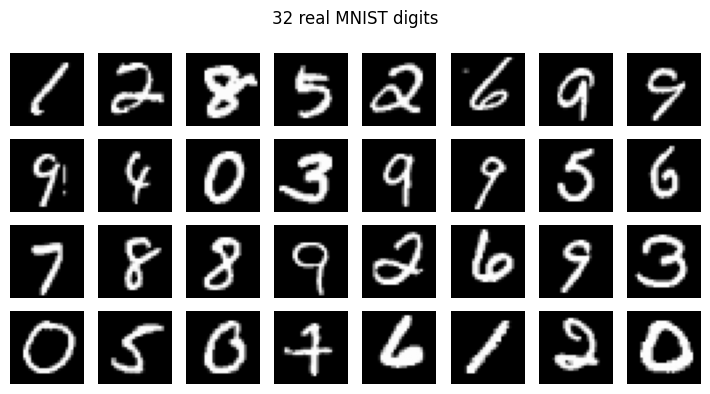

pixel range: -1.0 to 1.0
labels:      [1, 2, 8, 5, 2, 6, 9, 9, 9, 4, 0, 3, 9, 9, 5, 6, 7, 8, 8, 9, 2, 6, 9, 3, 0, 5, 0, 7, 6, 1, 2, 0]


In [5]:
real_batch, real_labels = next(iter(DataLoader(train_set, batch_size=32, shuffle=True)))
show_grid(real_batch, "32 real MNIST digits")
print("pixel range:", float(real_batch.min()), "to", float(real_batch.max()))
print("labels:     ", real_labels.tolist())

### A judge, because a GAN has no accuracy

A classifier is scored against labels. A generator has no labels to be scored against: there is no
right answer to "draw a digit". So you need an instrument. The standard one is a **pretrained
classifier**, run over a large batch of generated images, reading two things:

- **Which digits come out, and how many of each.** Real MNIST is about 10% of each digit. A healthy
  generator should be too. A generator that draws mostly one digit is the failure in task 2.6.
- **How confident the classifier is.** A crisp "7" gets a confident answer. A smudge also gets *an*
  answer — a classifier has to pick one of its ten classes — but, if the judge is any good, a hesitant
  one.

The cell below trains that judge: a small CNN, two epochs on the labelled training set, about 30
seconds. One detail is there because of what it will be judging. The digits a small generator draws
are **speckled** — stray white pixels around the strokes — and a classifier that has only ever seen
clean digits reads a speckled "1" as an "8", because the speckle fills in the loops an "8" has. So
the judge is trained with a little speckle sprinkled on its training images, and learns to read the
stroke underneath.

Then it reads 1,000 real test digits, and 1,000 images of pure noise. Look at the noise row before
moving on. The judge still names a digit for every noise image — it has to — but at 0.57
confidence on average, against 0.97 on real digits. Do not take that for granted: the same judge
trained *without* the speckle calls 92% of these noise images an "8" at 0.87 confidence. A classifier
only knows its ten classes, and shown something unlike its training data it picks the nearest one,
often confidently. So the judge's numbers are evidence, not proof. Whenever it reports a lot of one
digit, **look at the pictures before you believe it** — task 2.6 is where that matters.

`judge_report` is used in every task from here on. **`digits_covered`** counts the digits that make up
at least 2% of a batch, and **`top_share`** is the fraction taken by the most common one.

<div dir="rtl" align="right">

### حَكَم، لأن GAN لا دقّة لها

يُقيَّم المصنِّف مقابل التصنيفات. أمّا المولِّد فلا تصنيفات يُقيَّم مقابلها: فلا جواب صحيحًا لـ«ارسم رقمًا».
فتحتاج إلى أداة قياس. والأداة المعتادة **مصنِّف مُدرَّب مسبقًا** يُشغَّل على دفعة كبيرة من الصور المولَّدة،
ويُقرأ منه شيئان:

- **أيّ الأرقام تخرج، وكم من كلٍّ منها.** في MNIST الحقيقية نحو ١٠٪ من كل رقم، وينبغي أن يكون المولِّد السليم
  كذلك. والمولِّد الذي يرسم رقمًا واحدًا في الغالب هو الإخفاق في المهمة ٢٫٦.
- **مدى ثقة المصنِّف.** الرقم ٧ الواضح يحظى بجواب واثق. واللطخة تحظى *بجواب* أيضًا — فالمصنِّف مُجبَر على
  اختيار إحدى فئاته العشر — لكنه، إن كان الحَكَم جيّدًا، جواب متردّد.

والخلية أدناه تُدرّب ذلك الحَكَم: شبكة التفافية صغيرة، حقبتان على مجموعة التدريب المُصنَّفة، نحو ٣٠ ثانية.
وفيها تفصيل واحد سببه ما سيحكم عليه. فالأرقام التي يرسمها مولِّد صغير **مُنقَّطة** — بكسلات بيضاء شاردة حول
الخطوط — والمصنِّف الذي لم يرَ إلا أرقامًا نظيفة يقرأ الـ«١» المُنقَّط «٨»، لأن النقاط تملأ الحلقات التي في الـ«٨».
فيُدرَّب الحَكَم بقليل من النقاط المرشوشة على صور تدريبه، فيتعلّم أن يقرأ الخطّ الذي تحتها.

ثم يقرأ ١٬٠٠٠ رقم اختبار حقيقي، و١٬٠٠٠ صورة من الضجيج الخالص. انظر إلى سطر الضجيج قبل أن تمضي. فالحَكَم
ما زال يُسمّي رقمًا لكل صورة ضجيج — فهو مُجبَر على ذلك — لكن بثقة ٠٫٥٧ في المتوسّط، مقابل ٠٫٩٧ في
الأرقام الحقيقية. ولا تعدّ ذلك أمرًا مضمونًا: فالحَكَم نفسه مُدرَّبًا *بلا* نقاط يُسمّي ٩٢٪ من صور الضجيج هذه «٨»
بثقة ٠٫٨٧. فالمصنِّف لا يعرف إلا فئاته العشر، وحين يُعرض عليه شيء لا يشبه بيانات تدريبه يختار أقرب فئة، وكثيرًا
ما يختارها بثقة. فأعداد الحَكَم قرينة لا برهان. وكلّما أفاد بكثير من رقم واحد **فانظر إلى الصور قبل أن تُصدّقه**
— والمهمة ٢٫٦ هي حيث يهمّ ذلك.

وتُستعمل `judge_report` في كل مهمة من هنا. **`digits_covered`** تعدّ الأرقام التي تشكّل ٢٪ على الأقل من
الدفعة، و**`top_share`** هي الحصّة التي يأخذها أكثرها تكرارًا.

</div>

In [6]:
torch.manual_seed(SEED)
judge = nn.Sequential(
    nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),     # 28 -> 14
    nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),    # 14 -> 7
    nn.Flatten(), nn.Linear(32 * 7 * 7, 64), nn.ReLU(), nn.Linear(64, 10),
)
judge_optimiser = torch.optim.Adam(judge.parameters(), lr=1e-3)
started = time.perf_counter()
for _ in range(2):
    for images, labels in DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True):
        # Speckle: up to 5% of each image's pixels turned white, so that a speckled "1" is read as a 1.
        speckle = torch.rand_like(images) < 0.05 * torch.rand(len(images), 1, 1, 1)
        images = torch.where(speckle, 1.0, images)
        judge_optimiser.zero_grad()
        nn.functional.cross_entropy(judge(images), labels).backward()
        judge_optimiser.step()
judge.eval()
for parameter in judge.parameters():
    parameter.requires_grad = False          # the judge is an instrument: it never trains again

In [7]:
test_images = torch.stack([test_set[i][0] for i in range(len(test_set))])
test_labels = test_set.targets
with torch.no_grad():
    JUDGE_ACCURACY = (judge(test_images).argmax(1) == test_labels).float().mean().item()
print(f"judge: test accuracy {JUDGE_ACCURACY:.4f}, trained in {time.perf_counter() - started:.0f} s")

judge: test accuracy 0.9806, trained in 70 s


In [8]:
def judge_report(images):
    """What the judge sees in a batch of images in [-1, 1]."""
    with torch.no_grad():
        probabilities = judge(images).softmax(dim=1)
    counts = np.bincount(probabilities.argmax(dim=1).numpy(), minlength=10)
    shares = counts / counts.sum()
    return {"counts": counts,
            "digits_covered": int((shares >= 0.02).sum()),
            "top_share": float(shares.max()),
            "confidence": float(probabilities.max(dim=1).values.mean())}


def print_report(name, report_):
    print(f"{name:<22} counts {report_['counts'].tolist()}  covered {report_['digits_covered']:>2}/10  "
          f"top share {report_['top_share']:.2f}  confidence {report_['confidence']:.2f}")

In [9]:
REAL_REPORT = judge_report(test_images[:1000])
print_report("1,000 real digits", REAL_REPORT)
print_report("1,000 noise images", judge_report(torch.rand(1000, 1, 28, 28) * 2 - 1))

1,000 real digits      counts [85, 128, 120, 104, 111, 92, 86, 96, 87, 91]  covered 10/10  top share 0.13  confidence 0.97
1,000 noise images     counts [0, 9, 181, 23, 0, 556, 13, 1, 217, 0]  covered  4/10  top share 0.56  confidence 0.57


## Section 2 — Core: six tasks  (≈60 min)

1. The generator, as an `nn.Module`.
2. The discriminator, as an `nn.Module`.
3. One training step — the eight lines.
4. The training loop, and fifteen epochs.
5. Read what it learned: the curves, the pictures, and the judge.
6. Mode collapse: the normalisation layers removed, and the same run again.

Here is the whole game before you build it. Write **G** for the generator and **D** for the
discriminator. G takes a noise vector *z* — 64 numbers drawn from a standard normal — and returns an
image G(*z*). D takes any image and returns one score: high means "real", low means "fake". Each
training step has two halves:

| Half | Who learns | Shown | Told the answer is | So it learns to |
|---|---|---|---|---|
| D's half | D only | a batch of real images | real (1) | score real images high |
| | | a batch of G's images | fake (0) | score G's images low |
| G's half | G only | a fresh batch of G's images, through D | **real (1)** | make images D scores high |

Both halves use the same loss — binary cross-entropy, the one you met with logistic regression — and
pull it in opposite directions. Neither network ever sees the other's weights. G improves only by
being told, through D's gradient, which way to move its pixels to look more real.

<div dir="rtl" align="right">

## القسم الثاني — الأساسي: ست مهام (نحو ٦٠ دقيقة)

١. المولِّد صنفًا من `nn.Module`.
٢. المميِّز صنفًا من `nn.Module`.
٣. خطوة تدريب واحدة — الأسطر الثمانية.
٤. حلقة التدريب، وخمس عشرة حقبة.
٥. اقرأ ما تعلّمه: المنحنيات، والصور، والحَكَم.
٦. انهيار الأنماط: طبقات التطبيع منزوعة، والتشغيل نفسه مرّة أخرى.

وهذه اللعبة كلها قبل أن تبنيها. اكتب **G** للمولِّد و**D** للمميِّز. يأخذ G متّجه ضجيج *z* — ٦٤ عددًا مسحوبة
من توزيع طبيعي معياري — ويُرجع صورة G(*z*). ويأخذ D أي صورة ويُرجع درجة واحدة: العالية تعني «حقيقية»
والمنخفضة «مزيّفة». ولكل خطوة تدريب نصفان:

| النصف | من يتعلّم | يُعرض عليه | ويُقال له إن الجواب | فيتعلّم أن |
|---|---|---|---|---|
| نصف D | D وحده | دفعة صور حقيقية | حقيقية (1) | يُعطي الصور الحقيقية درجة عالية |
| | | دفعة من صور G | مزيّفة (0) | يُعطي صور G درجة منخفضة |
| نصف G | G وحده | دفعة جديدة من صور G، عبر D | **حقيقية (1)** | يصنع صورًا يُعطيها D درجة عالية |

ويستعمل النصفان الخسارة نفسها — الإنتروبيا التقاطعية الثنائية، التي عرفتها مع الانحدار اللوجستي — ويشدّانها
في اتجاهين متعاكسين. ولا ترى أيٌّ من الشبكتين أوزان الأخرى قطّ. ولا يتحسّن G إلا بأن يُقال له، عبر تدرّج D،
في أيّ اتجاه يحرّك بكسلاته ليبدو أكثر واقعية.

</div>

### Task 2.1 — the generator

A stack of linear layers that widens from 64 numbers to 784, then reshapes them into a 28×28 image.
Write it the way you wrote last week's networks: a class, the layers built in `__init__`, the data
flow in `forward`.

| Layer | Shape | Why |
|---|---|---|
| `Linear(64, 128)` → `BatchNorm1d` → `LeakyReLU(0.2)` | 64 → 128 | |
| `Linear(128, 256)` → `BatchNorm1d` → `LeakyReLU(0.2)` | 128 → 256 | each block widens |
| `Linear(256, 512)` → `BatchNorm1d` → `LeakyReLU(0.2)` | 256 → 512 | |
| `Linear(512, 784)` → `Tanh` | 512 → 784 | one output per pixel, in [−1, 1] |
| `.view(-1, 1, 28, 28)` in `forward` | 784 → 1×28×28 | back to an image |

Three choices to understand, not just type:

- **`Tanh` at the end** squeezes every pixel into [−1, 1] — the range the real images were put in.
- **`LeakyReLU(0.2)`** instead of ReLU. A ReLU passes zero gradient for every negative input, and a
  generator learns *only* through gradients that travel back from D. A leaky one lets 0.2 of the
  gradient through on the negative side, so no unit goes permanently silent.
- **`BatchNorm1d`** after each hidden linear layer, from W3D5. Here it matters more than it did for
  a classifier — task 2.6 is about what happens without it. The constructor takes a `batch_norm`
  argument so that task can switch it off: `nn.Identity` is a layer that returns its input unchanged,
  and `nn.Identity(128)` accepts and ignores the size, so the one line below picks either layer.

<div dir="rtl" align="right">

### المهمة ٢٫١ — المولِّد

رصّة من الطبقات الخطّية تتّسع من ٦٤ عددًا إلى ٧٨٤، ثم يُعاد تشكيلها صورةً ٢٨×٢٨. اكتبها كما كتبت شبكات
الأسبوع الماضي: صنف، والطبقات تُبنى في `__init__`، وتدفّق البيانات في `forward`.

| الطبقة | الشكل | لماذا |
|---|---|---|
| `Linear(64, 128)` ← `BatchNorm1d` ← `LeakyReLU(0.2)` | 64 ← 128 | |
| `Linear(128, 256)` ← `BatchNorm1d` ← `LeakyReLU(0.2)` | 128 ← 256 | كل كتلة تتّسع |
| `Linear(256, 512)` ← `BatchNorm1d` ← `LeakyReLU(0.2)` | 256 ← 512 | |
| `Linear(512, 784)` ← `Tanh` | 512 ← 784 | مخرج لكل بكسل، في [−1, 1] |
| `.view(-1, 1, 28, 28)` في `forward` | 784 ← 1×28×28 | العودة إلى صورة |

ثلاثة اختيارات تُفهم لا تُنسخ فقط:

- **`Tanh` في النهاية** تعصر كل بكسل في [−1, 1] — المدى الذي وُضعت فيه الصور الحقيقية.
- **`LeakyReLU(0.2)`** بدل ReLU. فـReLU تُمرّر تدرّجًا صفريًا لكل مدخل سالب، والمولِّد لا يتعلّم *إلا* عبر
  تدرّجات تعود إليه من D. والمسرّبة تُمرّر ٠٫٢ من التدرّج في الجانب السالب، فلا تصمت أي وحدة إلى الأبد.
- **`BatchNorm1d`** بعد كل طبقة خطّية مخفية، من الأسبوع ٣ اليوم ٥. وهنا تهمّ أكثر مما همّت في المصنِّف —
  فالمهمة ٢٫٦ عمّا يحدث بدونها. ويأخذ المُنشئ وسيطًا `batch_norm` لتستطيع تلك المهمة إطفاءها: `nn.Identity`
  طبقة تُرجع مدخلها كما هو، و`nn.Identity(128)` تقبل الحجم وتتجاهله، فيختار السطر أدناه إحدى الطبقتين.

</div>

In [10]:
class Generator(nn.Module):
    """64 noise numbers in, one 1x28x28 image in [-1, 1] out."""

    def __init__(self, latent_dim=LATENT_DIM, batch_norm=True):
        super().__init__()
        Norm = nn.BatchNorm1d if batch_norm else nn.Identity
        # TODO: self.net: three Linear -> Norm -> LeakyReLU(0.2) blocks (128, 256, 512), then Linear to 784 and Tanh.
        # مهمة: `self.net`: ثلاث كتل `Linear` ثم `Norm` ثم `LeakyReLU(0.2)` (١٢٨، ٢٥٦، ٥١٢)، ثم `Linear` إلى ٧٨٤ و`Tanh`.
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            Norm(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            Norm(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            Norm(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 784),
            nn.Tanh(),
        )

    def forward(self, z):
        # TODO: Through the network, then reshape the 784 numbers into a 1x28x28 image.
        # مهمة: عبر الشبكة، ثم أعِد تشكيل الأعداد الـ٧٨٤ صورةً 1x28x28.
        image = self.net(z).view(-1, 1, 28, 28)
        return image

noise (16, 64) -> images (16, 1, 28, 28), pixels from -0.93 to 0.94
generator parameters: 576,912


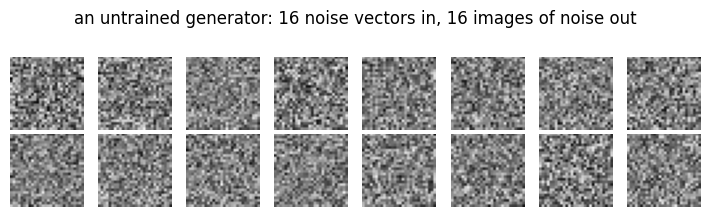

In [11]:
torch.manual_seed(SEED)
untrained = Generator()
z = torch.randn(16, LATENT_DIM)
fake = untrained(z)
print(f"noise {tuple(z.shape)} -> images {tuple(fake.shape)}, "
      f"pixels from {fake.min():.2f} to {fake.max():.2f}")
G_PARAMS = sum(p.numel() for p in untrained.parameters())
print(f"generator parameters: {G_PARAMS:,}")
show_grid(fake, "an untrained generator: 16 noise vectors in, 16 images of noise out")

### Task 2.2 — the discriminator

The mirror image: 784 pixels narrowing to **one number**.

| Layer | Shape |
|---|---|
| `Flatten` | 1×28×28 → 784 |
| `Linear(784, 512)` → `LayerNorm` → `LeakyReLU(0.2)` | 784 → 512 |
| `Linear(512, 256)` → `LayerNorm` → `LeakyReLU(0.2)` | 512 → 256 |
| `Linear(256, 128)` → `LayerNorm` → `LeakyReLU(0.2)` | 256 → 128 |
| `Linear(128, 1)` | 128 → 1 |

Two choices:

- **No sigmoid at the end.** D returns a raw score — a *logit* — and the loss is
  `nn.BCEWithLogitsLoss`, which applies the sigmoid inside, in a form that does not overflow when a
  score gets large. That is the same reason `CrossEntropyLoss` takes raw scores. To read D's output as
  a probability, apply `torch.sigmoid` yourself.
- **`LayerNorm`, not `BatchNorm1d`.** D is shown a batch of all-real images, then a batch of all-fake
  ones. Batch norm computes its statistics over the batch, so it would hand D a free clue — "this
  whole batch has the statistics of a fake batch" — instead of making it judge each image. Layer norm
  normalises each image's features on their own, so there is nothing to compare across the batch.
  As in the generator, a `layer_norm` argument lets task 2.6 switch it off.

<div dir="rtl" align="right">

### المهمة ٢٫٢ — المميِّز

الصورة المعكوسة: ٧٨٤ بكسلًا تضيق إلى **عدد واحد**.

| الطبقة | الشكل |
|---|---|
| `Flatten` | 1×28×28 ← 784 |
| `Linear(784, 512)` ← `LayerNorm` ← `LeakyReLU(0.2)` | 784 ← 512 |
| `Linear(512, 256)` ← `LayerNorm` ← `LeakyReLU(0.2)` | 512 ← 256 |
| `Linear(256, 128)` ← `LayerNorm` ← `LeakyReLU(0.2)` | 256 ← 128 |
| `Linear(128, 1)` | 128 ← 1 |

اختياران:

- **لا sigmoid في النهاية.** يُرجع D درجة خامًا — *logit* — والخسارة `nn.BCEWithLogitsLoss`، التي تُطبّق
  sigmoid في داخلها بصيغة لا تفيض حين تكبر الدرجة. وهو السبب نفسه الذي يجعل `CrossEntropyLoss` تأخذ درجات
  خامًا. ولتقرأ مخرج D احتمالًا، طبّق `torch.sigmoid` بنفسك.
- **`LayerNorm` لا `BatchNorm1d`.** يُعرض على D دفعة كلها حقيقية، ثم دفعة كلها مزيّفة. وتطبيع الدفعات يحسب
  إحصاءاته على الدفعة، فيُعطي D دليلًا مجّانيًا — «لهذه الدفعة كلها إحصاءات دفعة مزيّفة» — بدل أن يجعله يحكم
  على كل صورة. أمّا تطبيع الطبقة فيُطبّع سمات كل صورة وحدها، فلا شيء يُقارَن عبر الدفعة. وكما في المولِّد،
  يترك وسيط `layer_norm` المهمة ٢٫٦ تُطفئه.

</div>

In [12]:
class Discriminator(nn.Module):
    """One 1x28x28 image in, one raw score out: high = real, low = fake."""

    def __init__(self, layer_norm=True):
        super().__init__()
        Norm = nn.LayerNorm if layer_norm else nn.Identity
        # TODO: self.net: Flatten, three Linear -> Norm -> LeakyReLU(0.2) blocks (512, 256, 128), then Linear to a single score. No sigmoid.
        # مهمة: `self.net`: `Flatten`، وثلاث كتل `Linear` ثم `Norm` ثم `LeakyReLU(0.2)` (٥١٢، ٢٥٦، ١٢٨)، ثم `Linear` إلى درجة واحدة. بلا sigmoid.
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            Norm(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            Norm(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            Norm(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
        )

    def forward(self, image):
        # TODO: One raw score per image.
        # مهمة: درجة خام واحدة لكل صورة.
        score = self.net(image)
        return score

In [13]:
torch.manual_seed(SEED)
untrained_d = Discriminator()
scores = untrained_d(real_batch[:8])
print(f"images {tuple(real_batch[:8].shape)} -> scores {tuple(scores.shape)}")
print("raw scores:          ", scores.squeeze().detach().numpy().round(2))
print("as P(real), sigmoid: ", torch.sigmoid(scores).squeeze().detach().numpy().round(2))
D_PARAMS = sum(p.numel() for p in untrained_d.parameters())
print(f"discriminator parameters: {D_PARAMS:,}  (generator: {G_PARAMS:,})")

images (8, 1, 28, 28) -> scores (8, 1)
raw scores:           [0.78 0.7  0.61 0.77 0.7  0.85 0.86 0.89]
as P(real), sigmoid:  [0.69 0.67 0.65 0.68 0.67 0.7  0.7  0.71]
discriminator parameters: 568,065  (generator: 576,912)


An untrained D gives every image roughly the same score — it has no opinion yet, only random
weights. The two networks are almost
exactly the same size, 576,912 and 568,065 parameters. That is deliberate: if one is far stronger
than the other, the game is over before the weaker one learns anything.

<div dir="rtl" align="right">

يُعطي D غير المُدرَّب كل صورة الدرجة نفسها تقريبًا — فلا رأي له بعد، بل أوزان عشوائية فقط. والشبكتان بالحجم نفسه تقريبًا، ٥٧٦٬٩١٢ و٥٦٨٬٠٦٥
معاملًا. وهذا مقصود: فلو كانت إحداهما أقوى بكثير من الأخرى لانتهت اللعبة قبل أن تتعلّم الأضعف شيئًا.

</div>

### Task 2.3 — one training step

This is the heart of the lab: one batch of real images in, one update of D, one update of G, four
numbers out. Follow the table at the top of Section 2.

**D's half.**

1. Draw `n` noise vectors and make `fake = generator(z)`.
2. D's loss is the average of two BCE losses: D's scores on `real` against ones, and D's scores on
   **`fake.detach()`** against zeros.
3. `opt_d.zero_grad()`, `backward()`, `opt_d.step()`.

**G's half.**

4. G's loss is BCE between D's scores on a **fresh** batch of fakes — `generator(new noise)`, with
   nothing detached — and **ones**.
5. `opt_g.zero_grad()`, `backward()`, `opt_g.step()`.

The two lines every GAN bug lives in:

- **`.detach()` in D's half.** `fake` remembers that it came out of G. D's update has nothing to do
  with G, and `detach()` says so: the same pixels, with the history cut off. Leave it out and D's
  `backward()` runs on through G, filling G's `.grad` with gradients that point the wrong way — towards
  fakes that are *easier* to spot. In this code `opt_g.zero_grad()` happens to wipe them before G's own
  `backward()`, so the run would only be slower. Move that `zero_grad()` to the top of the function,
  as people do, and G spends every step half-learning to get caught. `detach()` removes the trap.
  In G's half you want the history — G learns *through* D — so nothing is detached there.
- **Ones as G's targets.** G is trained to make D say "real". The more obvious-looking alternative,
  *maximising* D's loss on fakes, gives G almost no gradient early on, exactly when D rejects every
  fake confidently and G most needs to learn. Labelling the fakes as real is the version that works,
  and the one used in practice.

Return D's loss, G's loss, and D's average opinion — `torch.sigmoid` of its scores — on the real
batch and on the fake batch. Those last two are the most readable numbers in GAN training.

<div dir="rtl" align="right">

### المهمة ٢٫٣ — خطوة تدريب واحدة

هذا قلب المعمل: دفعة واحدة من الصور الحقيقية تدخل، وتحديث واحد لـD، وتحديث واحد لـG، وأربعة أعداد تخرج.
اتبع الجدول في أول القسم الثاني.

**نصف D.**

١. اسحب `n` متّجه ضجيج واصنع `fake = generator(z)`.
٢. خسارة D متوسّط خسارتَي BCE: درجات D على `real` مقابل الآحاد، ودرجات D على **`fake.detach()`** مقابل
   الأصفار.
٣. `opt_d.zero_grad()` ثم `backward()` ثم `opt_d.step()`.

**نصف G.**

٤. خسارة G هي BCE بين درجات D على دفعة مزيّفة **جديدة** — `generator(ضجيج جديد)`، بلا فصل — و**الآحاد**.
٥. `opt_g.zero_grad()` ثم `backward()` ثم `opt_g.step()`.

والسطران اللذان يعيش فيهما كل خطأ في GAN:

- **`.detach()` في نصف D.** يتذكّر `fake` أنه خرج من G. وتحديث D لا شأن له بـG، و`detach()` تقول ذلك: البكسلات
  نفسها والتاريخ مقطوع. فإن حذفتها مضت `backward()` الخاصّة بـD عبر G، فملأت `.grad` الخاصّة بـG بتدرّجات تشير في
  الاتجاه الخطأ — نحو مزيّف *أسهل* كشفًا. وفي هذه الشيفرة يصادف أن `opt_g.zero_grad()` تمحوها قبل `backward()`
  الخاصّة بـG، فلا يكون التشغيل إلا أبطأ. لكن انقل `zero_grad()` إلى أول الدالّة، كما يفعل كثيرون، فيقضي G كل خطوة
  وهو يتعلّم نصف تعلّم أن يُكشَف. و`detach()` تُزيل الفخّ. وفي نصف G تريد التاريخ — فـG يتعلّم *عبر* D — فلا يُفصل
  شيء هناك.
- **الآحاد أهدافًا لـG.** يُدرَّب G ليجعل D يقول «حقيقية». والبديل الذي يبدو أوضح، أي *تعظيم* خسارة D على
  المزيّف، لا يُعطي G تدرّجًا يُذكر في البداية، بالضبط حين يرفض D كل مزيّف بثقة ويكون G أحوج ما يكون إلى
  التعلّم. وتصنيف المزيّف حقيقيًا هو الصيغة التي تعمل، والمستعملة في الواقع.

أرجِع خسارة D، وخسارة G، ورأي D المتوسّط — `torch.sigmoid` لدرجاته — في الدفعة الحقيقية وفي الدفعة المزيّفة.
وهذان الأخيران أوضح عددين يُقرآن في تدريب GAN.

</div>

In [14]:
criterion = nn.BCEWithLogitsLoss()


def train_step(real, generator, discriminator, opt_g, opt_d):
    """One update of D, then one of G. Returns d_loss, g_loss, D(real), D(fake)."""
    n = real.size(0)
    ones, zeros = torch.ones(n, 1), torch.zeros(n, 1)
    fake = generator(torch.randn(n, LATENT_DIM))

    # TODO: D's half: D's scores on real (target ones) and on detached fake (target zeros), the average of the two losses, then update D.
    # مهمة: نصف D: درجات D على الحقيقي (الهدف آحاد) وعلى المزيّف المفصول (الهدف أصفار)، ومتوسّط الخسارتين، ثم حدّث D.
    real_scores = discriminator(real)
    fake_scores = discriminator(fake.detach())
    d_real_loss = criterion(real_scores, ones)
    d_fake_loss = criterion(fake_scores, zeros)
    d_loss = (d_real_loss + d_fake_loss) / 2
    opt_d.zero_grad()
    d_loss.backward()
    opt_d.step()

    # TODO: G's half: D's scores on a fresh batch of fakes, nothing detached, against ones; update G.
    # مهمة: نصف G: درجات D على دفعة مزيّفة جديدة، بلا فصل، مقابل الآحاد؛ ثم حدّث G.
    fresh_fake = generator(torch.randn(n, LATENT_DIM))
    generator_scores = discriminator(fresh_fake)
    g_loss = criterion(generator_scores, ones)
    opt_g.zero_grad()
    g_loss.backward()
    opt_g.step()

    d_real = torch.sigmoid(real_scores).mean().item()
    d_fake = torch.sigmoid(fake_scores).mean().item()
    d_loss, g_loss = d_loss.item(), g_loss.item()
    return d_loss, g_loss, d_real, d_fake

In [15]:
torch.manual_seed(SEED)
g_try, d_try = Generator(), Discriminator()
opt_g_try = torch.optim.Adam(g_try.parameters(), lr=LEARNING_RATE, betas=BETAS)
opt_d_try = torch.optim.Adam(d_try.parameters(), lr=LEARNING_RATE, betas=BETAS)
for step, (real, _) in enumerate(train_loader):
    numbers = train_step(real, g_try, d_try, opt_g_try, opt_d_try)
    if step in (0, 1, 2, 50, 100):
        print(f"step {step:>3}: d_loss {numbers[0]:.3f}  g_loss {numbers[1]:.3f}  "
              f"D(real) {numbers[2]:.2f}  D(fake) {numbers[3]:.2f}")
    if step == 100:
        break

step   0: d_loss 0.704  g_loss 1.035  D(real) 0.44  D(fake) 0.44
step   1: d_loss 0.480  g_loss 1.094  D(real) 0.76  D(fake) 0.49
step   2: d_loss 0.401  g_loss 1.240  D(real) 0.85  D(fake) 0.47
step  50: d_loss 0.479  g_loss 1.850  D(real) 0.73  D(fake) 0.46
step 100: d_loss 0.693  g_loss 0.680  D(real) 0.56  D(fake) 0.55


Read the first rows. D starts near 0.5 on both, and within a few dozen steps it has pulled them
apart — real up, fake down — because telling noise from a digit is easy. **That is the normal start.**
D always leads early. The question is whether G catches up, and the next task answers it.

<div dir="rtl" align="right">

اقرأ الصفوف الأولى. يبدأ D قرب ٠٫٥ في الاثنين، وفي بضع عشرات من الخطوات يفصل بينهما — الحقيقي يصعد والمزيّف
ينزل — لأن تمييز الضجيج من الرقم سهل. **وهذه البداية الطبيعية.** فـD يتقدّم دائمًا في البداية. والسؤال: هل
يلحق به G؟ وتُجيب المهمة التالية.

</div>

### Task 2.4 — the training loop

`train_gan` builds the two optimisers, runs `train_step` over every batch for a number of epochs,
and at the end of each epoch records a row: the average of the four numbers, and the judge's report on
the same 1,000 **fixed** noise vectors. Fixed, because if the noise changed every epoch you could not
tell "G got better" from "G was handed easier noise". The function also keeps 32 of those images at
each epoch, so task 2.5 can show them in order.

Two settings that come from the GAN literature rather than from anything you have seen yet:

- **Adam with `betas=(0.5, 0.999)`.** The first beta is momentum. Its default, 0.9, keeps pushing in
  the direction of the last many steps. In a game, the direction that was right a moment ago is often
  wrong now, because the other network has moved. Less momentum lets each network react. This setting
  comes from the DCGAN paper (Radford et al., 2015), and almost every GAN since uses it.
- **One learning rate for both, 2e-4.** Neither network should outrun the other.

`sample` — given — draws images in evaluation mode with no gradients, which is how you look at a
generator. That matters here because the generator has batch norm: in `eval()` it uses the running
statistics, so an image depends only on its own noise vector and not on the rest of the batch.

Fifteen epochs take about four minutes. Start it, then read task 2.5 while it runs.

<div dir="rtl" align="right">

### المهمة ٢٫٤ — حلقة التدريب

تبني `train_gan` المُحسِّنَين، وتُشغّل `train_step` على كل دفعة لعدد من الحقب، وفي نهاية كل حقبة تُسجّل صفًّا:
متوسّط الأعداد الأربعة، وتقرير الحَكَم على متّجهات الضجيج الألف **الثابتة** نفسها. ثابتة، لأن الضجيج لو تغيّر
كل حقبة لما استطعت أن تفرّق «تحسّن G» من «أُعطي G ضجيجًا أسهل». وتحتفظ الدالّة أيضًا بـ٣٢ من تلك الصور في كل
حقبة، لتعرضها المهمة ٢٫٥ بالترتيب.

وضبطان يأتيان من أدبيات GAN لا من شيء رأيته بعد:

- **Adam بـ`betas=(0.5, 0.999)`.** البيتا الأولى هي الزخم. وقيمتها الافتراضية ٠٫٩ تواصل الدفع في اتجاه
  الخطوات الكثيرة الأخيرة. وفي اللعبة، كثيرًا ما يصير الاتجاه الذي كان صحيحًا قبل لحظة خطأً الآن، لأن الشبكة
  الأخرى تحرّكت. والزخم الأقل يترك كل شبكة تستجيب. وهذا الضبط من ورقة DCGAN (Radford وزملاؤه، ٢٠١٥)،
  وتستعمله كل GAN تقريبًا بعدها.
- **معدّل تعلّم واحد للاثنتين، 2e-4.** فلا ينبغي لإحدى الشبكتين أن تسبق الأخرى.

ودالّة `sample` — المُعطاة — ترسم الصور في وضع التقييم بلا تدرّجات، وهكذا يُنظر إلى المولِّد. وهذا مهمّ هنا
لأن في المولِّد تطبيع دفعات: ففي `eval()` يستعمل الإحصاءات المتحرّكة، فتعتمد الصورة على متّجه ضجيجها وحده
لا على بقية الدفعة.

وتستغرق الحقب الخمس عشرة نحو أربع دقائق. ابدأها، ثم اقرأ المهمة ٢٫٥ أثناء عملها.

</div>

In [16]:
torch.manual_seed(SEED)
FIXED_Z = torch.randn(1000, LATENT_DIM)       # the same 1,000 noise vectors, every epoch


def sample(generator, z=FIXED_Z):
    generator.eval()
    with torch.no_grad():
        images = generator(z)
    generator.train()
    return images

In [17]:
def train_gan(generator, discriminator, epochs, name):
    opt_g = torch.optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=BETAS)
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=BETAS)
    rows, snapshots = [], []
    for epoch in range(1, epochs + 1):
        started = time.perf_counter()
        totals = np.zeros(4)
        # TODO: Every batch of train_loader through train_step, its four numbers added to totals.
        # مهمة: كل دفعة من `train_loader` عبر `train_step`، وأعدادها الأربعة تُضاف إلى `totals`.
        for real, _ in train_loader:
            totals += np.asarray(train_step(real, generator, discriminator, opt_g, opt_d))
        d_loss, g_loss, d_real, d_fake = totals / len(train_loader)
        images = sample(generator)
        report_ = judge_report(images)
        rows.append({"run": name, "epoch": epoch, "d_loss": d_loss, "g_loss": g_loss,
                     "d_real": d_real, "d_fake": d_fake,
                     "digits_covered": report_["digits_covered"],
                     "top_share": report_["top_share"], "confidence": report_["confidence"],
                     **{f"share_{d}": c / 1000 for d, c in enumerate(report_["counts"])},
                     "seconds": time.perf_counter() - started})
        snapshots.append(images[:32])
        row = rows[-1]
        print(f"epoch {epoch:>2}: d_loss {row['d_loss']:.3f}  g_loss {row['g_loss']:.3f}  "
              f"D(real) {row['d_real']:.2f}  D(fake) {row['d_fake']:.2f}  |  covered "
              f"{row['digits_covered']}/10  top share {row['top_share']:.2f}  "
              f"confidence {row['confidence']:.2f}  ({row['seconds']:.0f} s)")
    return pd.DataFrame(rows), snapshots

In [18]:
torch.manual_seed(SEED)
generator, discriminator = Generator(), Discriminator()
history, snapshots = train_gan(generator, discriminator, EPOCHS, name="healthy")

epoch  1: d_loss 0.611  g_loss 1.153  D(real) 0.58  D(fake) 0.43  |  covered 10/10  top share 0.19  confidence 0.59  (28 s)
epoch  2: d_loss 0.587  g_loss 1.117  D(real) 0.59  D(fake) 0.41  |  covered 10/10  top share 0.21  confidence 0.69  (28 s)
epoch  3: d_loss 0.523  g_loss 1.307  D(real) 0.64  D(fake) 0.37  |  covered 10/10  top share 0.19  confidence 0.72  (28 s)
epoch  4: d_loss 0.516  g_loss 1.352  D(real) 0.64  D(fake) 0.36  |  covered 10/10  top share 0.18  confidence 0.77  (28 s)
epoch  5: d_loss 0.519  g_loss 1.342  D(real) 0.64  D(fake) 0.36  |  covered 10/10  top share 0.15  confidence 0.79  (28 s)
epoch  6: d_loss 0.508  g_loss 1.365  D(real) 0.65  D(fake) 0.35  |  covered 10/10  top share 0.15  confidence 0.80  (28 s)
epoch  7: d_loss 0.502  g_loss 1.398  D(real) 0.66  D(fake) 0.34  |  covered 10/10  top share 0.16  confidence 0.82  (28 s)
epoch  8: d_loss 0.505  g_loss 1.382  D(real) 0.65  D(fake) 0.34  |  covered 10/10  top share 0.14  confidence 0.82  (27 s)
epoch  9

### Task 2.5 — read what it learned

Three views of the same run. Write the code for the second and the third; the first is given.

**The curves.** Look at them before you read on. Neither loss goes down to zero, and that is the
point: each network's loss is the other's success. If D's loss went to zero, D would be winning
outright and G would be getting no useful gradient; if G's loss went to zero, D would have stopped
working. A healthy run settles into a stalemate where **D(real) stays above D(fake)** — D can still
tell, a bit — and nothing explodes. Here D(real) ends near 0.67 and D(fake) near 0.33. A GAN
loss curve tells you whether the game is still being played. It does **not** tell you whether the
images are good. For that you look, and you measure.

**The pictures.** The same 32 noise vectors at epochs 1, 2, 5 and 15. Each *position* in the grid
is one noise vector, so you are watching the same 32 "ideas" become digits.

**The judge.** Run `judge_report` on the 1,000 fixed-noise images from the final generator and compare
it with the real digits from Section 1: a bar for each digit, generated beside real.

<div dir="rtl" align="right">

### المهمة ٢٫٥ — اقرأ ما تعلّمه

ثلاث نظرات إلى التشغيل نفسه. اكتب شيفرة الثانية والثالثة؛ والأولى مُعطاة.

**المنحنيات.** انظر إليها قبل أن تكمل القراءة. لا تنزل أيٌّ من الخسارتين إلى الصفر، وهذا هو المقصود: فخسارة
كل شبكة نجاح للأخرى. ولو نزلت خسارة D إلى الصفر لكان D يفوز فوزًا تامًّا ولما وصل G تدرّج مفيد؛ ولو نزلت خسارة
G إلى الصفر لكان D قد توقّف عن العمل. والتشغيل السليم يستقرّ على تعادل يبقى فيه **D(real) فوق D(fake)** —
فما زال D يميّز قليلًا — ولا ينفجر شيء. وهنا ينتهي D(real) قرب ٠٫٦٧ وD(fake) قرب ٠٫٣٣. ومنحنى خسارة
GAN يُخبرك أن اللعبة ما زالت تُلعب، **ولا** يُخبرك أن الصور جيّدة. ولذلك تنظر، وتقيس.

**الصور.** متّجهات الضجيج الـ٣٢ نفسها في الحقب ١ و٢ و٥ و١٥. وكل *موضع* في الشبكة متّجه ضجيج واحد،
فأنت تراقب «الأفكار» الـ٣٢ نفسها تصير أرقامًا.

**الحَكَم.** شغّل `judge_report` على صور الضجيج الثابت الألف من المولِّد النهائي وقارنها بالأرقام الحقيقية من
القسم الأول: عمود لكل رقم، المولَّد بجانب الحقيقي.

</div>

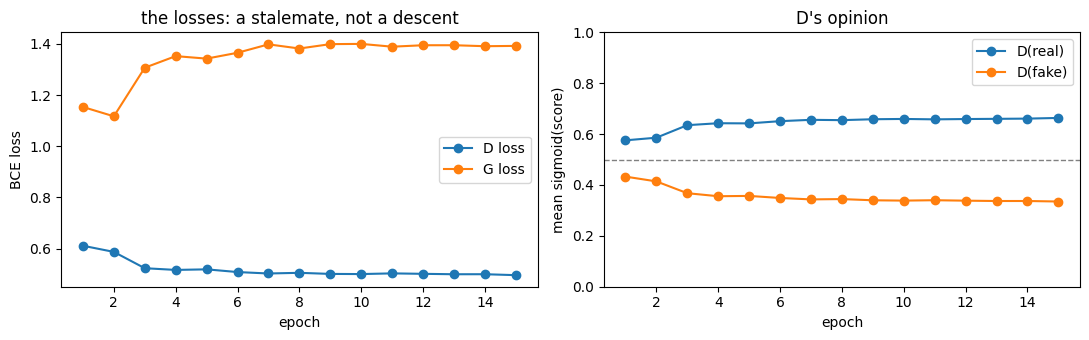

In [19]:
fig, (ax_loss, ax_d) = plt.subplots(1, 2, figsize=(11, 3.5))
ax_loss.plot(history["epoch"], history["d_loss"], marker="o", label="D loss")
ax_loss.plot(history["epoch"], history["g_loss"], marker="o", label="G loss")
ax_loss.set(xlabel="epoch", ylabel="BCE loss", title="the losses: a stalemate, not a descent")
ax_d.plot(history["epoch"], history["d_real"], marker="o", label="D(real)")
ax_d.plot(history["epoch"], history["d_fake"], marker="o", label="D(fake)")
ax_d.axhline(0.5, color="grey", linestyle="--", linewidth=1)
ax_d.set(xlabel="epoch", ylabel="mean sigmoid(score)", ylim=(0, 1), title="D's opinion")
for ax in (ax_loss, ax_d):
    ax.legend()
plt.tight_layout()
plt.show()

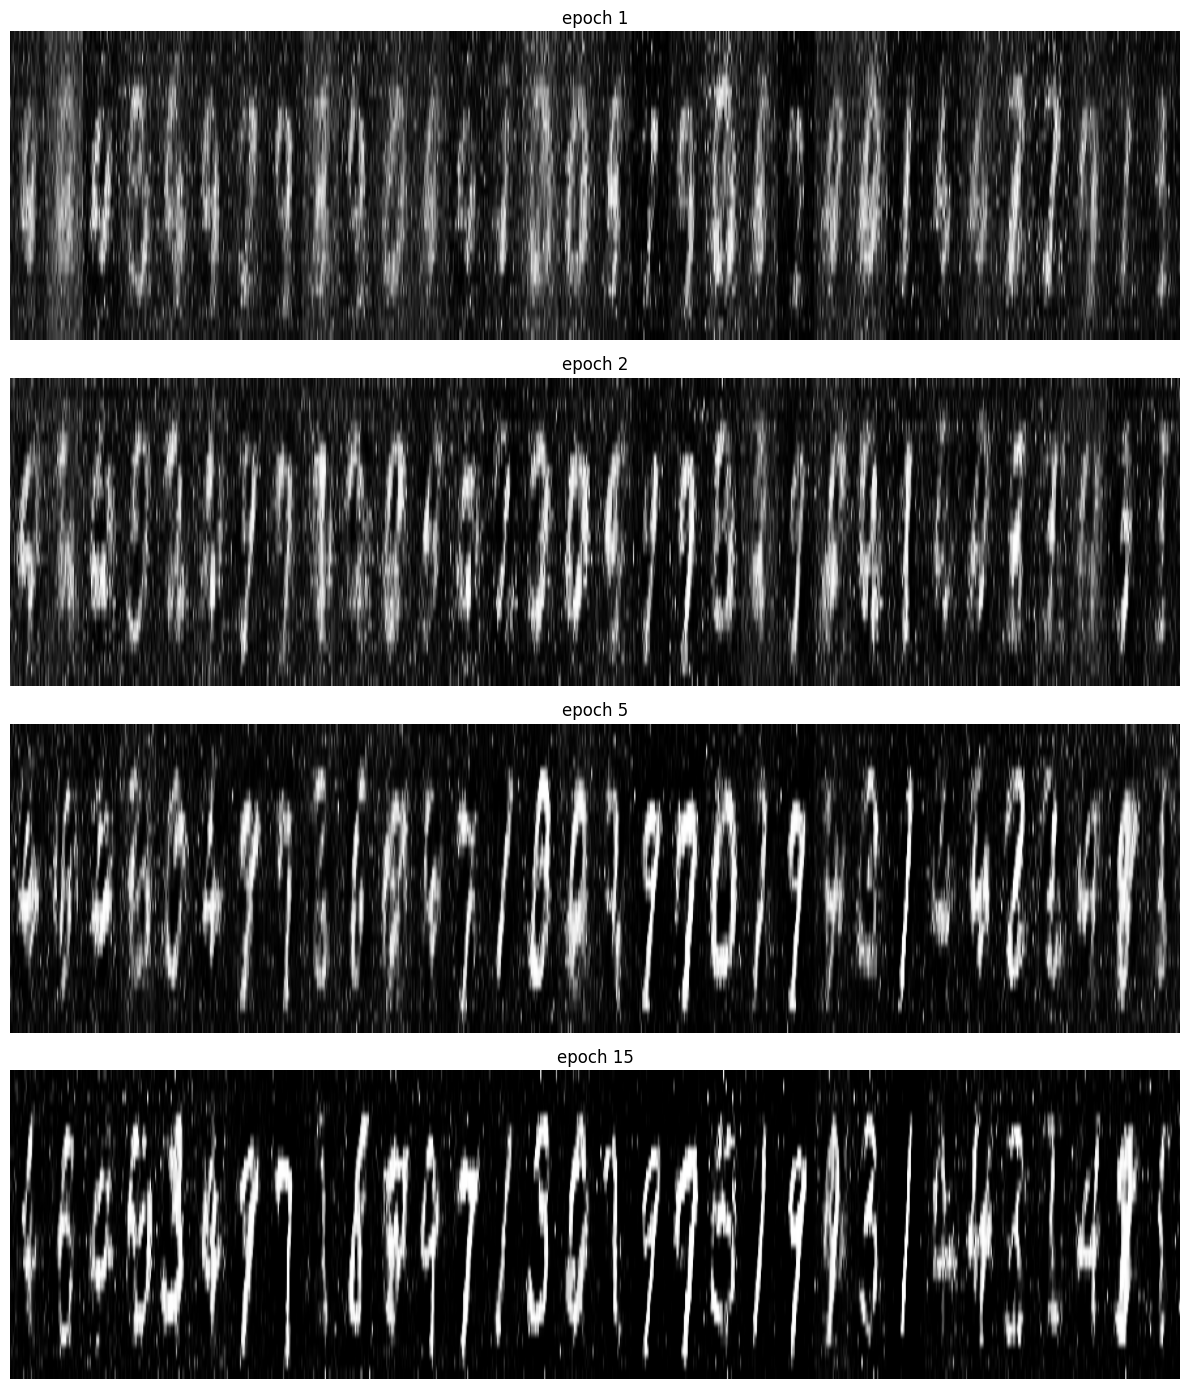

In [20]:
# TODO: The same 32 noise vectors at epochs 1, 2, 5 and EPOCHS.
# مهمة: متّجهات الضجيج الـ٣٢ نفسها في الحقب ١ و٢ و٥ و`EPOCHS`.
snapshots_to_show = [0, 1, 4, EPOCHS - 1]
fig, axes = plt.subplots(len(snapshots_to_show), 1, figsize=(12, 3.5 * len(snapshots_to_show)))
for ax, epoch_index in zip(np.ravel(axes), snapshots_to_show):
    ax.imshow(
        np.concatenate([image.squeeze().numpy() for image in snapshots[epoch_index]], axis=1),
        cmap="gray",
        vmin=-1,
        vmax=1,
        aspect="auto",
    )
    ax.set_title(f"epoch {epoch_index + 1}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [21]:
# TODO: FINAL_REPORT: the judge's report on the 1,000 fixed-noise images of the final generator.
# مهمة: `FINAL_REPORT`: تقرير الحَكَم على صور الضجيج الثابت الألف من المولِّد النهائي.
FINAL_REPORT = judge_report(sample(generator))

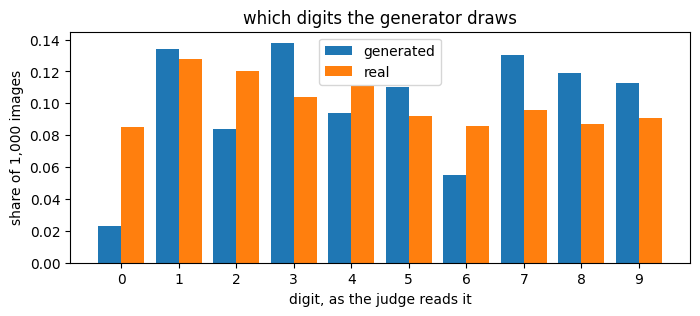

1,000 real digits      counts [85, 128, 120, 104, 111, 92, 86, 96, 87, 91]  covered 10/10  top share 0.13  confidence 0.97
1,000 generated        counts [23, 134, 84, 138, 94, 110, 55, 130, 119, 113]  covered 10/10  top share 0.14  confidence 0.87


In [22]:
digits = np.arange(10)
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(digits - 0.2, FINAL_REPORT["counts"] / 1000, width=0.4, label="generated")
ax.bar(digits + 0.2, REAL_REPORT["counts"] / 1000, width=0.4, label="real")
ax.set(xticks=digits, xlabel="digit, as the judge reads it", ylabel="share of 1,000 images",
       title="which digits the generator draws")
ax.legend()
plt.show()
print_report("1,000 real digits", REAL_REPORT)
print_report("1,000 generated", FINAL_REPORT)

On the machine this notebook was written on, the generator covered **9 of 10** digits,
the most common one taking 0.16 of the batch, with the judge 0.87 confident on average — against
0.97 on real digits. So it draws nearly every digit in roughly the right proportions, and not
quite as cleanly as a person: the speckle around the strokes is what the gap in confidence measures.
Now look at the bar that is missing. The "0" is drawn for 1.6% of the noise vectors against
8.5% of real digits, and the "6" is short too. The generator has partly **dropped** two digits. That
is a mild form of the problem in the next task, and it is invisible in the losses and easy to miss in
a 32-image grid — you only see it because you counted 1,000.

<div dir="rtl" align="right">

على الجهاز الذي كُتب عليه هذا الدفتر غطّى المولِّد **٩ من ١٠** أرقام، وأخذ أكثرها تكرارًا ٠٫١٦ من
الدفعة، وكانت ثقة الحَكَم ٠٫٨٧ في المتوسّط — مقابل ٠٫٩٧ على الأرقام الحقيقية. فهو يرسم كل الأرقام
تقريبًا بنسب صحيحة تقريبًا، وليس بنظافة يد إنسان تمامًا: فالنقاط المتناثرة حول الخطوط هي ما يقيسه فرق الثقة.
والآن انظر إلى العمود الناقص. فالـ«٠» يُرسم لـ١٫٦٪ من متّجهات الضجيج مقابل ٨٫٥٪ من الأرقام الحقيقية،
والـ«٦» ناقص أيضًا. فقد **أسقط** المولِّد رقمين جزئيًا. وهذه صورة خفيفة من مشكلة المهمة التالية، لا تظهر في
الخسارتين، ويسهل أن تفوتك في شبكة من ٣٢ صورة — ولم ترها إلا لأنك عددت ألفًا.

</div>

### Task 2.6 — mode collapse

**What it is.** MNIST has ten *modes* — ten clusters of images that look alike, one per digit. A
generator that has **collapsed** has stopped covering them: most noise vectors, however different,
come out as the same digit, sometimes the same image. The individual images can look perfectly good.
What is lost is the variety.

**Why it happens.** Read G's loss again: BCE between D's score on each fake image and "real". It is
an average over images, each judged **alone**. Nothing in it asks whether the batch is varied. If one
kind of image fools D best — say a "1", which is a single stroke and the easiest digit to fake — then
the fastest way down G's loss is to make *every* noise vector into that "1". D then learns that "1"s
are suspicious and pushes their scores down, and G's fastest way down moves to some other digit. The
run hops from mode to mode, and never spreads over all ten. That hopping is the fingerprint.

**What prevents it.** In these two networks, the normalisation layers. Batch norm in the generator
normalises each layer over the batch, so the activations for one noise vector are pulled into the
same distribution as everyone else's, and a batch where every vector produces the same activations
is hard to keep. The DCGAN paper reports exactly this: batch norm in the generator "proved critical …
preventing the generator from collapsing all samples to a single point, which is a common failure
mode observed in GANs". Layer norm in the discriminator keeps its scores from swinging hard; without
it D over-reacts to whatever G is drawing this minute, and G over-reacts back — which is the hopping.

**The experiment.** Train a second GAN with `Generator(batch_norm=False)` and
`Discriminator(layer_norm=False)` — two arguments changed, everything else identical — for
8 epochs, and read it with the same instruments:

1. the grid of its 32 fixed-noise images at the last epoch;
2. a heat map of the judge's digit shares, **epoch by epoch, for both runs** — rows are epochs, columns
   are digits. A healthy run is an even wash across all ten columns. A collapsed one is a single bright
   column, and if it hops you see the bright cell move;
3. `COLLAPSED_REPORT` on the final collapsed generator, printed beside `FINAL_REPORT`.

Then write `FINDING`: one sentence that says what you saw in the collapsed run — which digit or digits
it drew, its top share, and how that compares with the healthy run.

<div dir="rtl" align="right">

### المهمة ٢٫٦ — انهيار الأنماط

**ما هو.** في MNIST عشرة *أنماط* — عشرة عناقيد من الصور المتشابهة، عنقود لكل رقم. والمولِّد الذي **انهار**
توقّف عن تغطيتها: فمعظم متّجهات الضجيج، مهما اختلفت، تخرج الرقمَ نفسه، وأحيانًا الصورة نفسها. وقد تبدو كل
صورة جيّدة تمامًا. والذي يضيع هو التنوّع.

**لماذا يحدث.** اقرأ خسارة G مرّة أخرى: BCE بين درجة D على كل صورة مزيّفة و«حقيقية». وهي متوسّط على صور تُحكَم
كلٌّ منها **وحدها**. ولا شيء فيها يسأل أمتنوّعة الدفعة أم لا. فإن كان نوع واحد من الصور يخدع D أكثر من غيره —
لنقل «١»، وهو ضربة قلم واحدة وأسهل الأرقام تزييفًا — فأسرع طريق لخفض خسارة G أن يجعل *كل* متّجه ضجيج ذلك
الـ«١». ثم يتعلّم D أن الآحاد مُريبة فيخفض درجاتها، فينتقل أسرع طريق لـG إلى رقم آخر. فيقفز التشغيل من نمط إلى
نمط، ولا ينتشر على العشرة كلها. وهذا القفز هو البصمة.

**ما يمنعه.** في هاتين الشبكتين، طبقات التطبيع. فتطبيع الدفعات في المولِّد يُطبّع كل طبقة على الدفعة، فتُشدّ تنشيطات
متّجه الضجيج الواحد إلى التوزيع نفسه الذي لغيره، ويصعب الإبقاء على دفعة يُنتج فيها كل متّجه التنشيطات نفسها.
وهذا بالضبط ما تذكره ورقة DCGAN: تطبيع الدفعات في المولِّد «كان حاسمًا … في منع المولِّد من أن يُطبق كل العيّنات
على نقطة واحدة، وهو نمط إخفاق شائع في GAN». أمّا تطبيع الطبقة في المميِّز فيمنع درجاته من التأرجح الشديد؛ وبدونه
يُفرط D في الاستجابة لما يرسمه G في هذه اللحظة، ويُفرط G في الاستجابة بدوره — وهذا هو القفز.

**التجربة.** درّب GAN ثانية بـ`Generator(batch_norm=False)` و`Discriminator(layer_norm=False)` — وسيطان
تغيّرا وكل شيء آخر كما هو — لثماني حقب، واقرأها بالأدوات نفسها:

١. شبكة صورها الـ٣٢ من الضجيج الثابت في الحقبة الأخيرة؛
٢. خريطة حرارية لحصص الأرقام عند الحَكَم، **حقبة بحقبة، للتشغيلين** — الصفوف حقب والأعمدة أرقام. والتشغيل
   السليم لون متساوٍ على الأعمدة العشرة كلها. والمنهار عمود ساطع واحد، وإن قفز رأيت الخلية الساطعة تتحرّك؛
٣. `COLLAPSED_REPORT` على المولِّد المنهار النهائي، مطبوعًا بجانب `FINAL_REPORT`.

ثم اكتب `FINDING`: جملة واحدة تقول ما رأيته في التشغيل المنهار — أيّ رقم أو أرقام رسمها، وحصّته العليا، وكيف
يُقارن ذلك بالتشغيل السليم.

</div>

In [23]:
# TODO: The same GAN with no normalisation in either network, for COLLAPSE_EPOCHS epochs.
# مهمة: GAN نفسها بلا تطبيع في أيٍّ من الشبكتين، لـ`COLLAPSE_EPOCHS` حقب.
torch.manual_seed(SEED)
collapsed_generator = Generator(batch_norm=False)
collapsed_discriminator = Discriminator(layer_norm=False)
collapsed_history, collapsed_snapshots = train_gan(
    collapsed_generator, collapsed_discriminator, COLLAPSE_EPOCHS, name="no normalisation"
)

epoch  1: d_loss 0.400  g_loss 1.701  D(real) 0.81  D(fake) 0.39  |  covered 2/10  top share 0.57  confidence 0.34  (27 s)
epoch  2: d_loss 0.208  g_loss 3.720  D(real) 0.89  D(fake) 0.16  |  covered 3/10  top share 0.52  confidence 0.46  (27 s)
epoch  3: d_loss 0.195  g_loss 3.960  D(real) 0.89  D(fake) 0.12  |  covered 2/10  top share 0.52  confidence 0.65  (27 s)
epoch  4: d_loss 0.203  g_loss 3.490  D(real) 0.88  D(fake) 0.13  |  covered 6/10  top share 0.34  confidence 0.78  (28 s)
epoch  5: d_loss 0.222  g_loss 3.112  D(real) 0.87  D(fake) 0.13  |  covered 5/10  top share 0.49  confidence 0.81  (26 s)
epoch  6: d_loss 0.179  g_loss 3.068  D(real) 0.89  D(fake) 0.11  |  covered 4/10  top share 0.83  confidence 0.89  (27 s)
epoch  7: d_loss 0.161  g_loss 3.163  D(real) 0.91  D(fake) 0.09  |  covered 4/10  top share 0.79  confidence 0.88  (27 s)
epoch  8: d_loss 0.174  g_loss 3.105  D(real) 0.90  D(fake) 0.10  |  covered 7/10  top share 0.73  confidence 0.86  (27 s)


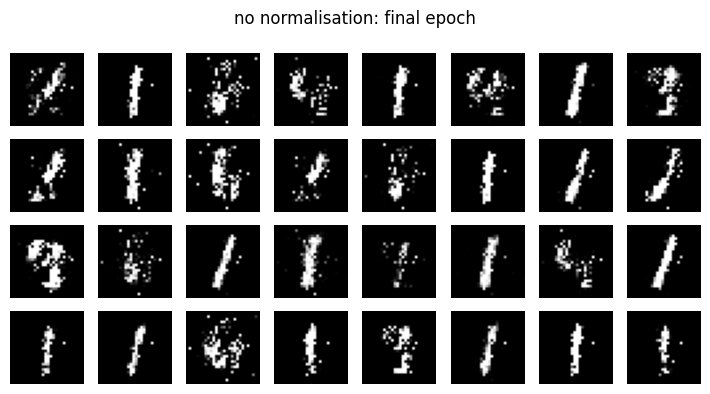

In [24]:
# TODO: Its 32 fixed-noise images at the last epoch.
# مهمة: صوره الـ٣٢ من الضجيج الثابت في الحقبة الأخيرة.
show_grid(collapsed_snapshots[-1], "no normalisation: final epoch")

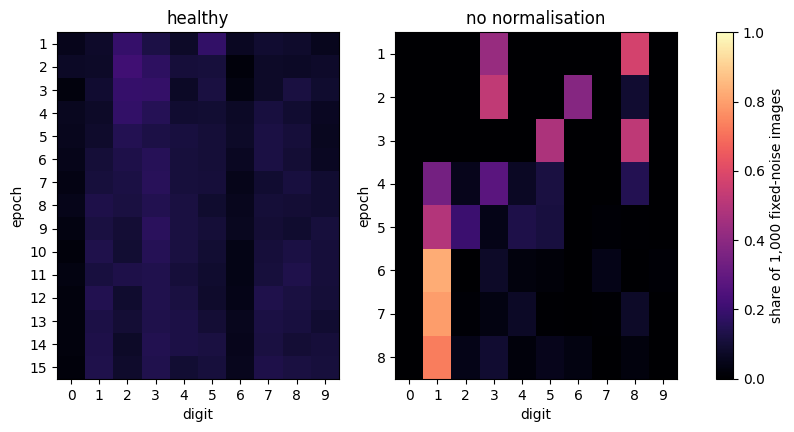

In [25]:
share_columns = [f"share_{d}" for d in range(10)]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, frame, title in zip(axes, (history, collapsed_history), ("healthy", "no normalisation")):
    shown = ax.imshow(frame[share_columns].to_numpy(), vmin=0, vmax=1, cmap="magma", aspect="auto")
    ax.set(xticks=range(10), yticks=range(len(frame)), yticklabels=frame["epoch"],
           xlabel="digit", ylabel="epoch", title=title)
fig.colorbar(shown, ax=axes, label="share of 1,000 fixed-noise images")
plt.show()

In [26]:
# TODO: COLLAPSED_REPORT on the final collapsed generator, printed beside FINAL_REPORT.
# مهمة: `COLLAPSED_REPORT` على المولِّد المنهار النهائي، مطبوعًا بجانب `FINAL_REPORT`.
COLLAPSED_REPORT = judge_report(sample(collapsed_generator))
print_report("healthy generator", FINAL_REPORT)
print_report("no normalisation", COLLAPSED_REPORT)

healthy generator      counts [23, 134, 84, 138, 94, 110, 55, 130, 119, 113]  covered 10/10  top share 0.14  confidence 0.87
no normalisation       counts [0, 729, 45, 91, 22, 54, 34, 0, 25, 0]  covered  7/10  top share 0.73  confidence 0.86


In [27]:
# TODO: One sentence: what did the collapsed run draw, and how does it compare with the healthy one?
# مهمة: جملة واحدة: ماذا رسم التشغيل المنهار، وكيف يُقارن بالسليم؟
collapsed_counts = COLLAPSED_REPORT["counts"]
collapsed_top_digit = int(np.argmax(collapsed_counts))
FINDING = (
    f"The collapsed run drew mostly digit {collapsed_top_digit}, with a top share of "
    f"{COLLAPSED_REPORT['top_share']:.2f}, compared with {FINAL_REPORT['top_share']:.2f} for "
    f"the healthy run, which covered {FINAL_REPORT['digits_covered']} digits."
)
print(FINDING)

The collapsed run drew mostly digit 1, with a top share of 0.73, compared with 0.14 for the healthy run, which covered 10 digits.


**Read the two heat maps together.** The healthy map is an even wash across the columns from epoch 4 on. The no-normalisation map is not. Its bright cell starts on "8" (99% of the batch at epoch 1), jumps to "7" (92%), back to "8" and "4", spreads out for one epoch — and from epoch 5 locks onto "1", at 50–78%. That is mode hopping, then collapse onto the easiest digit to fake. The grid agrees: most of the 32 fixed-noise images are the same upright "1", from noise vectors that in the healthy generator drew every digit. And D is winning: D(real) and D(fake) end at 0.90 and 0.10, against 0.67 and 0.33 in the healthy run — a generator that draws one thing is easy to catch, and yet it does not escape.

Batch norm is one remedy, not the only one, and you will meet the others by name:

- **Minibatch discrimination** (Salimans et al., 2016) and its simpler descendant, the **minibatch
  standard deviation** layer (Karras et al., 2018), show D a statistic of the *whole batch*. A batch of
  identical images then looks fake to D, so collapse stops paying.
- **Wasserstein GANs** (Arjovsky et al., 2017) change the loss so that D's gradient stays informative
  even when D is winning, which removes much of the incentive to hop.
- **Unrolled GANs** let G look a few D-steps ahead, so it can see that the "1" it is converging on is
  about to be punished.

None of these is a guarantee. Mode collapse is still the first thing to check when a generative model
looks too good on a handful of samples — which is why you measured 1,000.

<div dir="rtl" align="right">

**اقرأ الخريطتين الحراريتين معًا.** الخريطة السليمة لون متساوٍ على الأعمدة من الحقبة الرابعة فصاعدًا. أمّا خريطة «بلا تطبيع» فلا. تبدأ خليّتها الساطعة على «٨» (٩٩٪ من الدفعة في الحقبة الأولى)، ثم تقفز إلى «٧» (٩٢٪)، ثم تعود إلى «٨» و«٤»، وتنتشر حقبة واحدة — ومن الحقبة الخامسة تثبت على «١» بنسبة ٥٠–٧٨٪. وهذا قفز بين الأنماط، ثم انهيار على أسهل رقم تزييفًا. والشبكة توافق: فمعظم الصور الـ٣٢ من الضجيج الثابت هي الـ«١» القائم نفسه، من متّجهات ضجيج كانت في المولِّد السليم ترسم كل رقم. وD هو الفائز: إذ ينتهي D(real) وD(fake) عند ٠٫٩٠ و٠٫١٠، مقابل ٠٫٦٧ و٠٫٣٣ في التشغيل السليم — فالمولِّد الذي يرسم شيئًا واحدًا سهل الكشف، ومع ذلك لا يفلت.

وتطبيع الدفعات علاج واحد لا الوحيد، وستلقى الآخرين بأسمائهم:

- **التمييز على الدفعة** (minibatch discrimination، ‏Salimans وزملاؤه، ٢٠١٦) وخَلَفه الأبسط، طبقة **الانحراف
  المعياري للدفعة** (Karras وزملاؤه، ٢٠١٨)، يُريان D إحصاءً من *الدفعة كلها*. فتبدو الدفعة من الصور المتطابقة
  مزيّفة لـD، فيكفّ الانهيار عن أن يُجدي.
- **Wasserstein GAN** ‏(Arjovsky وزملاؤه، ٢٠١٧) تُغيّر الخسارة فيبقى تدرّج D مُفيدًا حتى حين يفوز D، فيزول كثير
  من دافع القفز.
- **Unrolled GAN** تترك G ينظر بضع خطوات من D إلى الأمام، فيرى أن الـ«١» الذي يتقارب نحوه على وشك أن يُعاقَب.

ولا شيء من هذه ضمان. فانهيار الأنماط ما زال أول ما يُفحص حين يبدو نموذج توليدي ممتازًا على حفنة من العيّنات —
ولهذا قِست ألفًا.

</div>

## Section 3 — Stretch: walking through the noise  (≈30 min)

The generator is a function from 64 numbers to an image. So you can ask what lies *between* two
images: take the noise vector of one generated digit, *z*₁, and of another, *z*₂, and generate from
the points on the straight line between them,

  *z*(*t*) = (1 − *t*) · *z*₁ + *t* · *z*₂, for *t* = 0, 0.1, …, 1.

If the generator had memorised a list of training images, the middle of that line would be garbage
or a sudden jump. If it has learned something about how digits are drawn, the middle is a sequence of
plausible strokes that morph one digit into the other.

Pick two of the 1,000 fixed noise vectors that the judge reads as **different** digits, with
confidence above 0.9 each, and draw the eleven steps in one row. Do it for three pairs. Then the same
for the **collapsed** generator, and write two sentences comparing the two: what does a collapsed
generator's noise space look like when you walk across it?

<div dir="rtl" align="right">

## القسم الثالث — الإضافي: المشي في الضجيج (نحو ٣٠ دقيقة)

المولِّد دالّة من ٦٤ عددًا إلى صورة. فتستطيع أن تسأل ماذا يقع *بين* صورتين: خذ متّجه ضجيج رقم مولَّد، *z*₁،
ومتّجه رقم آخر، *z*₂، وولِّد من النقاط على الخطّ المستقيم بينهما،

  *z*(*t*) = (1 − *t*) · *z*₁ + *t* · *z*₂، حيث *t* = 0 و0.1 و… و1.

لو حفظ المولِّد قائمة من صور التدريب لكان وسط ذلك الخطّ هراءً أو قفزة مفاجئة. ولو تعلّم شيئًا عن كيفية رسم
الأرقام لكان الوسط سلسلة من الضربات المعقولة تُحوّل رقمًا إلى آخر.

اختر اثنين من متّجهات الضجيج الثابتة الألف يقرؤهما الحَكَم رقمين **مختلفين**، بثقة فوق ٠٫٩ لكلٍّ منهما، وارسم
الخطوات الإحدى عشرة في صف واحد. افعل ذلك لثلاثة أزواج. ثم الشيء نفسه للمولِّد **المنهار**، واكتب جملتين تقارن
بينهما: كيف يبدو فضاء الضجيج لمولِّد منهار حين تمشي فيه؟

</div>

In [28]:
# TODO: Three pairs of noise vectors the judge reads, confidently, as different digits.
# مهمة: ثلاثة أزواج من متّجهات الضجيج يقرؤها الحَكَم، بثقة، أرقامًا مختلفة.
candidate_images = sample(generator)
with torch.no_grad():
    candidate_probabilities = judge(candidate_images).softmax(dim=1)
candidate_labels = candidate_probabilities.argmax(dim=1)
candidate_confidence = candidate_probabilities.max(dim=1).values
pairs = []
for i in range(len(FIXED_Z)):
    if candidate_confidence[i].item() <= 0.9:
        continue
    for j in range(i + 1, len(FIXED_Z)):
        if candidate_confidence[j].item() > 0.9 and candidate_labels[i].item() != candidate_labels[j].item():
            pairs.append((i, j))
            break
    if len(pairs) == 3:
        break
INTERPOLATION_PAIRS = pairs

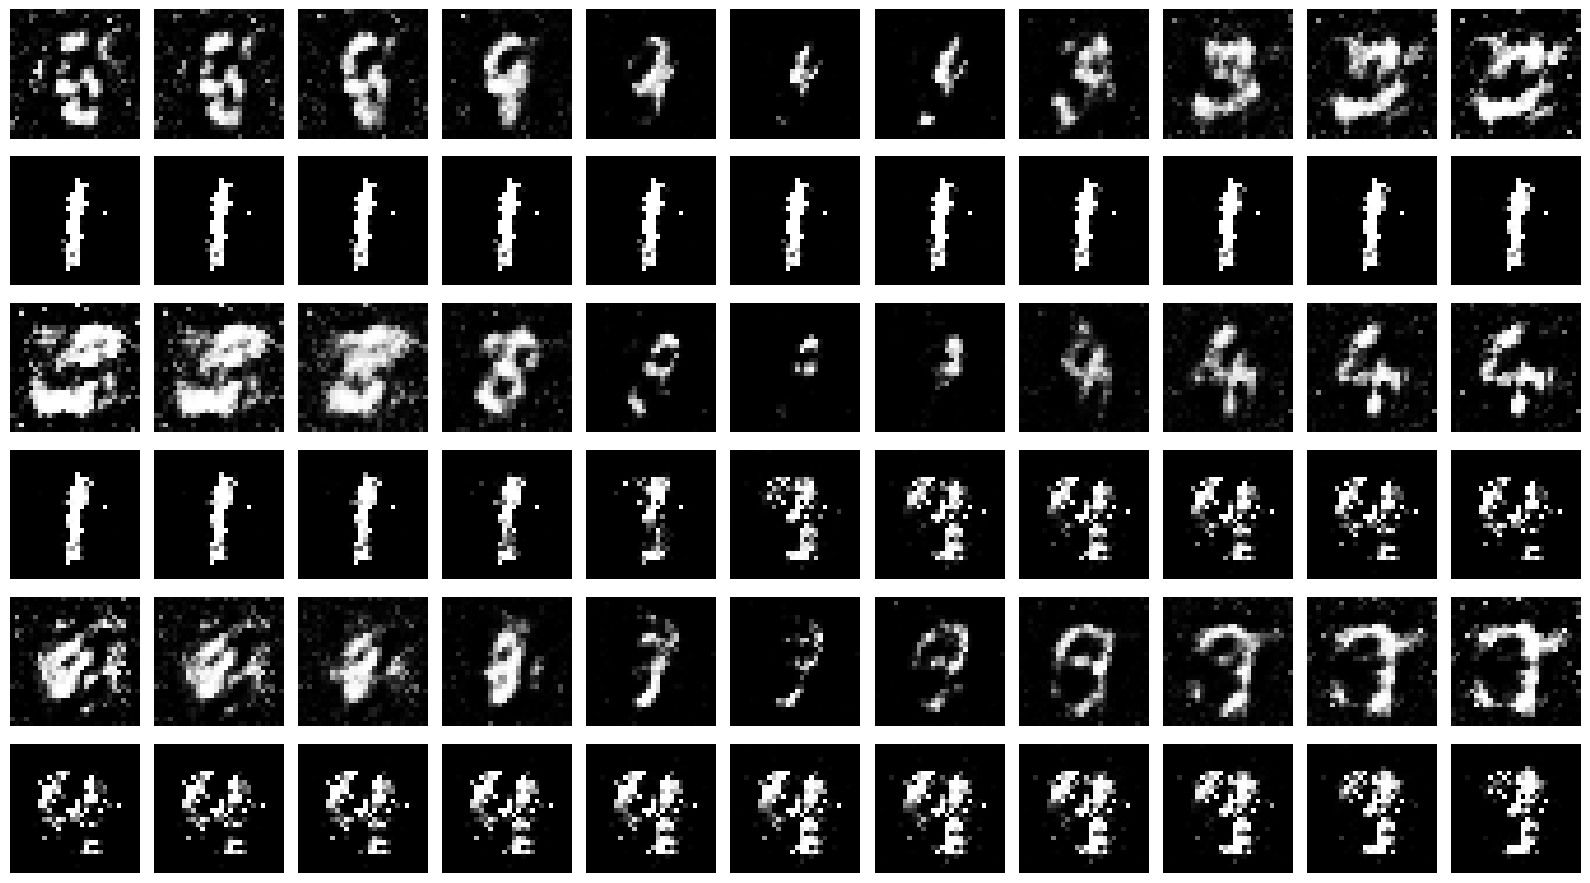

The healthy generator changes digits smoothly across the latent-space walks, while the collapsed generator stays near a small set of modes and changes less reliably between different endpoints.
The healthy run covered 10 digits with a top share of 0.14, whereas the collapsed run concentrated on digit 1 with a top share of 0.73.


In [29]:
# TODO: An 11-step walk between each pair, through the healthy and the collapsed generator.
# مهمة: مشي من ١١ خطوة بين كل زوج، عبر المولِّد السليم والمنهار.
steps = torch.linspace(0, 1, 11)
fig, axes = plt.subplots(6, 11, figsize=(16, 9))
for pair_index, (i, j) in enumerate(INTERPOLATION_PAIRS):
    walk = torch.stack([(1 - t) * FIXED_Z[i] + t * FIXED_Z[j] for t in steps])
    healthy_walk = generator(walk).detach()
    collapsed_walk = collapsed_generator(walk).detach()
    for step_index in range(11):
        axes[2 * pair_index, step_index].imshow(
            healthy_walk[step_index].squeeze(), cmap="gray", vmin=-1, vmax=1
        )
        axes[2 * pair_index, step_index].axis("off")
        axes[2 * pair_index + 1, step_index].imshow(
            collapsed_walk[step_index].squeeze(), cmap="gray", vmin=-1, vmax=1
        )
        axes[2 * pair_index + 1, step_index].axis("off")
    axes[2 * pair_index, 0].set_ylabel("healthy")
    axes[2 * pair_index + 1, 0].set_ylabel("collapsed")
plt.tight_layout()
plt.show()
print(
    "The healthy generator changes digits smoothly across the latent-space walks, while the collapsed generator "
    "stays near a small set of modes and changes less reliably between different endpoints."
)
print(
    f"The healthy run covered {FINAL_REPORT['digits_covered']} digits with a top share of "
    f"{FINAL_REPORT['top_share']:.2f}, whereas the collapsed run concentrated on digit "
    f"{int(np.argmax(COLLAPSED_REPORT['counts']))} with a top share of {COLLAPSED_REPORT['top_share']:.2f}."
)

## Save your artefacts

Two files. `generator.pt` holds the healthy generator's **state dict** — the weights only — plus what
is needed to rebuild it: the latent size, the seed and the judge's verdict. The discriminator is not
saved. Once training is over it has done its job; to *use* a GAN you only ever need G and some noise.
`gan_history.parquet` is one row per epoch for both runs, with the judge's numbers, so the heat maps
of task 2.6 can be redrawn without training anything.

<div dir="rtl" align="right">

## احفظ آثارك

ملفّان. `generator.pt` يحفظ **قاموس حالة** المولِّد السليم — الأوزان فقط — ومعه ما يلزم لإعادة بنائه: طول
متّجه الضجيج، والبذرة، وحكم الحَكَم. ولا يُحفظ المميِّز. فقد أدّى عمله حين انتهى التدريب؛ ولكي *تستعمل* GAN لا
تحتاج إلا إلى G وبعض الضجيج. و`gan_history.parquet` صف لكل حقبة للتشغيلين، مع أعداد الحَكَم، فتُعاد رسم
الخريطتين الحراريتين في المهمة ٢٫٦ دون تدريب أي شيء.

</div>

In [30]:
GENERATOR_PATH = ARTEFACT_DIR / "generator.pt"
HISTORY_PATH = ARTEFACT_DIR / "gan_history.parquet"

torch.save({"generator_state_dict": generator.state_dict(),
            "latent_dim": LATENT_DIM,
            "batch_norm": True,
            "epochs": EPOCHS,
            "seed": SEED,
            "digits_covered": FINAL_REPORT["digits_covered"],
            "top_share": FINAL_REPORT["top_share"],
            "confidence": FINAL_REPORT["confidence"]}, GENERATOR_PATH)

In [31]:
gan_history = pd.concat([history, collapsed_history], ignore_index=True)
gan_history.to_parquet(HISTORY_PATH, index=False)

print(f"wrote {GENERATOR_PATH.name} ({GENERATOR_PATH.stat().st_size / 1024:.0f} KB) and "
      f"{HISTORY_PATH.name} ({len(gan_history)} rows)")
print(gan_history[["run", "epoch", "d_loss", "g_loss", "d_real", "d_fake",
                   "digits_covered", "top_share", "confidence"]].round(3).to_string(index=False))

wrote generator.pt (2268 KB) and gan_history.parquet (23 rows)
             run  epoch  d_loss  g_loss  d_real  d_fake  digits_covered  top_share  confidence
         healthy      1   0.611   1.153   0.575   0.433              10      0.189       0.592
         healthy      2   0.587   1.117   0.586   0.414              10      0.213       0.686
         healthy      3   0.523   1.307   0.635   0.368              10      0.191       0.721
         healthy      4   0.516   1.352   0.643   0.356              10      0.181       0.766
         healthy      5   0.519   1.342   0.642   0.357              10      0.146       0.785
         healthy      6   0.508   1.365   0.651   0.349              10      0.155       0.802
         healthy      7   0.502   1.398   0.656   0.343              10      0.157       0.821
         healthy      8   0.505   1.382   0.655   0.345              10      0.144       0.823
         healthy      9   0.501   1.399   0.658   0.340              10      0.162

## Sanity check

The last check rebuilds a generator from nothing but the saved file and confirms it draws exactly the
same images from the same noise.

<div dir="rtl" align="right">

## فحص سلامة

يُعيد الفحص الأخير بناء مولِّد من الملف المحفوظ وحده، ويتأكّد أنه يرسم الصور نفسها تمامًا من الضجيج نفسه.

</div>

In [32]:
probe = Generator()(torch.randn(16, LATENT_DIM))
check(tuple(probe.shape) == (16, 1, 28, 28) and probe.min() >= -1 and probe.max() <= 1,
      f"the generator must turn (16, 64) noise into (16, 1, 28, 28) images in [-1, 1] — got "
      f"{tuple(probe.shape)}, range {probe.min():.2f} to {probe.max():.2f}",
      f"يجب أن يحوّل المولِّد ضجيجًا (16, 64) إلى صور (16, 1, 28, 28) في [-1, 1] — والناتج "
      f"{tuple(probe.shape)}، والمدى من {probe.min():.2f} إلى {probe.max():.2f}")

g_count = sum(p.numel() for p in Generator().parameters())
d_count = sum(p.numel() for p in Discriminator().parameters())
no_bn = (not any(isinstance(m, nn.BatchNorm1d) for m in Generator(batch_norm=False).modules())
         and not any(isinstance(m, nn.LayerNorm) for m in Discriminator(layer_norm=False).modules()))
check(g_count == 576_912 and d_count == 568_065 and no_bn,
      f"the generator should have 576,912 parameters and the discriminator 568,065, and "
      f"the batch_norm=False / layer_norm=False versions no normalisation layer — got {g_count:,}, "
      f"{d_count:,}, normalisation removed: {no_bn}",
      f"يجب أن يكون للمولِّد ٥٧٦٬٩١٢ معاملًا وللمميِّز ٥٦٨٬٠٦٥، وألّا يكون في "
      f"نسختَي `batch_norm=False` و`layer_norm=False` أي طبقة تطبيع — والناتج {g_count:,} و{d_count:,}، "
      f"وأُزيل التطبيع: {no_bn}")

True

In [33]:
d_out = Discriminator()(real_batch[:4])
check(tuple(d_out.shape) == (4, 1) and not isinstance(list(Discriminator().modules())[-1], nn.Sigmoid),
      f"the discriminator must return one raw score per image, shape (4, 1), with no sigmoid — "
      f"got {tuple(d_out.shape)}",
      f"يجب أن يُرجع المميِّز درجة خامًا واحدة لكل صورة، بشكل (4, 1)، بلا sigmoid — "
      f"والناتج {tuple(d_out.shape)}")

True

In [34]:
check(len(history) == EPOCHS and len(collapsed_history) == COLLAPSE_EPOCHS
      and np.isfinite(gan_history[["d_loss", "g_loss"]].to_numpy()).all(),
      f"one finite row per epoch for each run — got {len(history)} and {len(collapsed_history)} rows",
      f"صف واحد منتهٍ لكل حقبة في كل تشغيل — والموجود {len(history)} و{len(collapsed_history)} صفًّا")

check(history["d_real"].iloc[-1] > history["d_fake"].iloc[-1],
      f"at the end of a healthy run D should still score real images above fakes — got D(real) "
      f"{history['d_real'].iloc[-1]:.2f}, D(fake) {history['d_fake'].iloc[-1]:.2f}",
      f"في نهاية التشغيل السليم يجب أن يظلّ D يُعطي الحقيقي درجة أعلى من المزيّف — والناتج D(real) "
      f"{history['d_real'].iloc[-1]:.2f} وD(fake) {history['d_fake'].iloc[-1]:.2f}")

True

In [35]:
check(FINAL_REPORT["digits_covered"] >= 8 and FINAL_REPORT["top_share"] <= 0.3
      and FINAL_REPORT["confidence"] >= 0.75,
      f"the healthy generator should draw at least 8 digits, none above 30% of the batch, with the judge "
      f"at least 0.75 confident — got {FINAL_REPORT['digits_covered']} digits, top share "
      f"{FINAL_REPORT['top_share']:.2f}, confidence {FINAL_REPORT['confidence']:.2f}",
      f"يجب أن يرسم المولِّد السليم ٨ أرقام على الأقل، ولا يتجاوز أيٌّ منها ٣٠٪ من الدفعة، وثقة الحَكَم ٠٫٧٥ "
      f"على الأقل — والناتج {FINAL_REPORT['digits_covered']} أرقام، والحصّة العليا "
      f"{FINAL_REPORT['top_share']:.2f}، والثقة {FINAL_REPORT['confidence']:.2f}")

check(COLLAPSED_REPORT["top_share"] >= 0.4,
      f"without normalisation the generator should collapse: one digit should take at least 40% of the "
      f"final batch (the healthy run: {FINAL_REPORT['top_share']:.2f}) — got "
      f"{COLLAPSED_REPORT['top_share']:.2f}. Check that task 2.6 switched off both normalisations",
      f"بلا تطبيع يجب أن ينهار المولِّد: يجب أن يأخذ رقم واحد ٤٠٪ على الأقل من الدفعة الأخيرة "
      f"(والتشغيل السليم: {FINAL_REPORT['top_share']:.2f}) — والناتج {COLLAPSED_REPORT['top_share']:.2f}. "
      f"تأكّد أن المهمة ٢٫٦ أطفأت التطبيعين كليهما")

True

In [36]:
saved = torch.load(GENERATOR_PATH, map_location="cpu", weights_only=True)
rebuilt = Generator(latent_dim=saved["latent_dim"], batch_norm=saved["batch_norm"])
rebuilt.load_state_dict(saved["generator_state_dict"])
check(torch.equal(sample(rebuilt, FIXED_Z[:64]), sample(generator, FIXED_Z[:64])),
      "a generator rebuilt from generator.pt must draw exactly the same images from the same noise",
      "يجب أن يرسم مولِّد أُعيد بناؤه من `generator.pt` الصور نفسها تمامًا من الضجيج نفسه")

check(len(str(FINDING).split()) >= 12,
      f"task 2.6 wants a sentence, not a placeholder — got {len(str(FINDING).split())} words",
      f"تريد المهمة ٢٫٦ جملة لا عبارة نائبة — والموجود {len(str(FINDING).split())} كلمة")

report()

──────────────────────────────────────────────────────────────────
  ✓  the generator must turn (16, 64) noise into (16, 1, 28, 28) images in [-1, 1] — got (16, 1, 28, 28), range -0.92 to 0.94
  ✓  the generator should have 576,912 parameters and the discriminator 568,065, and the batch_norm=False / layer_norm=False versions no normalisation layer — got 576,912, 568,065, normalisation removed: True
  ✓  the discriminator must return one raw score per image, shape (4, 1), with no sigmoid — got (4, 1)
  ✓  one finite row per epoch for each run — got 15 and 8 rows
  ✓  at the end of a healthy run D should still score real images above fakes — got D(real) 0.66, D(fake) 0.33
  ✓  the healthy generator should draw at least 8 digits, none above 30% of the batch, with the judge at least 0.75 confident — got 10 digits, top share 0.14, confidence 0.87
  ✓  without normalisation the generator should collapse: one digit should take at least 40% of the final batch (the healthy run: 0.14) — got 0.73

## What's next

The week is done. You can pool and augment, borrow a pretrained backbone and train only its head,
segment and detect, and — today — train a network that makes images instead of labelling them.

**Week 5** leaves images for text. The adversarial game does not come with you, but today's instrument
does: when a model *produces* something — a sentence, a summary, an answer — there is no accuracy to
print, and you measure it the way you measured the generator, with a second model and with your eyes
on a large sample.

**Week 6** comes back to generation from another side. An autoencoder also maps a short vector to an
image, but it is trained to *reconstruct* rather than to fool, and it does not collapse — at the price
of blurrier images. Keep today's grids; you will want them for the comparison.

<div dir="rtl" align="right">

## ما التالي

انتهى الأسبوع. تستطيع الآن أن تُجمّع وتُكثّر، وأن تستعير عمودًا فقريًا مُدرَّبًا مسبقًا ولا تُدرّب إلا رأسه، وأن
تُقطّع وتكشف، و— اليوم — أن تُدرّب شبكة تصنع الصور بدل أن تُصنّفها.

**والأسبوع الخامس** يترك الصور إلى النصوص. ولا تأتي معك اللعبة التنافسية، لكن أداة اليوم تأتي: فحين *يُنتج*
نموذج شيئًا — جملة، أو ملخّصًا، أو جوابًا — لا دقّة تُطبع، فتقيسه كما قست المولِّد، بنموذج ثانٍ وبعينيك على
عيّنة كبيرة.

**والأسبوع السادس** يعود إلى التوليد من جهة أخرى. فالمُرمِّز التلقائي (autoencoder) يحوّل أيضًا متّجهًا قصيرًا
إلى صورة، لكنه يُدرَّب على *إعادة البناء* لا على الخداع، ولا ينهار — بثمن صور أكثر ضبابية. فاحتفظ بشبكات
اليوم؛ ستريدها للمقارنة.

</div>